## Import library

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

# import kagglehub
import pandas as pd
import numpy as np

import seaborn as sns
sns.set(color_codes = True)
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
from scipy.stats import randint, uniform

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR, LinearSVR, NuSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor


## Load Data

In [108]:
train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

In [109]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [110]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [111]:
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [112]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [113]:
train_data.describe(include = 'object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


In [114]:
test_data.describe(include = 'object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1455,1459,107,1459,1459,1457,1459,1459,1459,1459,1459,1459,1459,1459,1459,1458,1458,565,1459,1459,1459,1415,1414,1415,1417,1417,1459,1459,1459,1459,1458,1457,729,1383,1381,1381,1381,1459,3,290,51,1458,1459
unique,5,2,2,4,4,1,5,3,25,9,5,5,7,6,4,13,15,3,4,5,6,4,4,4,6,6,4,5,2,4,4,7,5,6,3,4,5,3,2,4,3,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,1114,1453,70,934,1311,1457,1081,1396,218,1251,1444,1205,745,1169,1442,510,510,434,892,1256,661,634,1295,951,431,1237,1446,752,1358,1337,757,1357,364,853,625,1293,1328,1301,2,172,46,1258,1204


In [115]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [116]:
test_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,1458.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1457.000000,1457.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.00000,1381.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,52.619342,554.294925,1046.117970,1156.534613,325.967786,3.543523,1486.045922,0.434454,0.065202,1.570939,0.377656,2.854010,1.042495,6.385195,0.58122,1977.721217,1.766118,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,176.753926,437.260486,442.898624,398.165820,420.610226,44.043251,485.566099,0.530648,0.252468,0.555190,0.503017,0.829788,0.208472,1.508895,0.64742,26.431175,0.775945,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000,0.000000,407.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.00000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,0.000000,219.250000,784.000000,873.500000,0.000000,0.000000,1117.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.00000,1959.000000,1.000000,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,0.000000,460.000000,988.000000,1079.000000,0.000000,0.000000,1432.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,0.00000,1979.000000,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,0.000000,797.750000,1305.000000,1382.500000,676.000000,0.000000,1721.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.00000,2002.000000,2.000000,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,1526.000000,2140.000000,5095.000000,5095.000000,1862.000000,1064.000000,5095.000000,3.000000,2.000000,4.000000,2.000000,6.000000,2.000000,15.000000,4.00000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


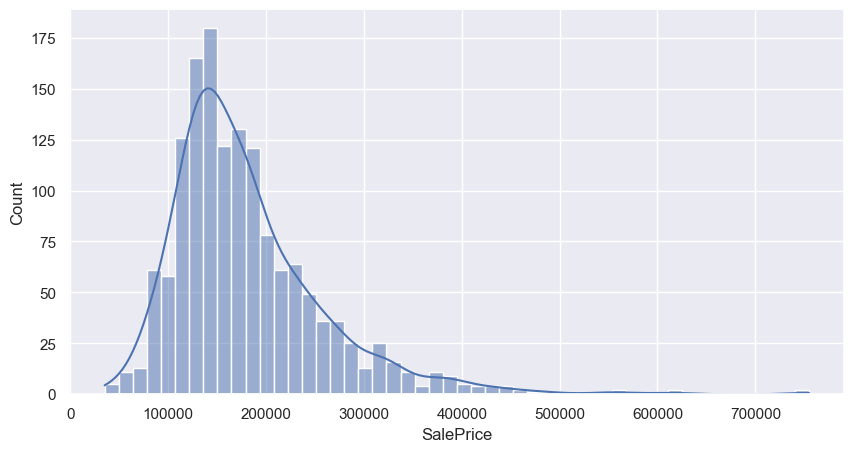

In [ ]:
# Target variable
# Examine skewness, outliers, and distribution shape to understand how house prices are distributed.
# Histogram
plt.figure(figsize = (10, 5))

sns.histplot(
    train_data['SalePrice'],
    bins = 50, 
    kde = True
)

plt.show()

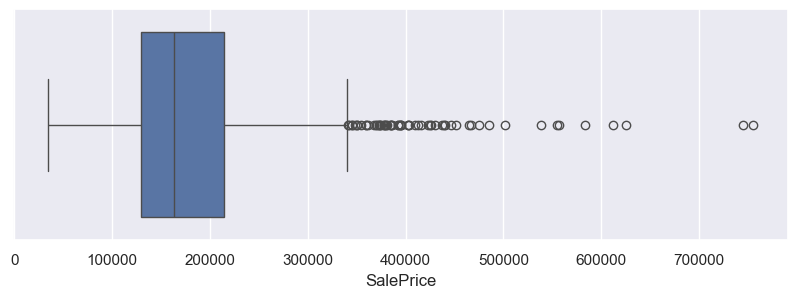

In [ ]:
# Boxplot
# Median, quartiles, and outliers — to identify extreme values.

plt.figure(figsize = (10, 3))
sns.boxplot(x = train_data['SalePrice'])
plt.show()

In [119]:
train_data.nlargest(10, 'SalePrice')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,6,1994,1995,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455,Unf,0,989,2444,GasA,Ex,Y,SBrkr,2444,1872,0,4316,0,1,3,1,4,1,Ex,10,Typ,2,Ex,Attchd,1994.0,Fin,3,832,TA,TA,Y,382,50,0,0,0,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1996,1996,Hip,CompShg,Wd Sdng,ImStucc,NaN,0.0,Gd,TA,PConc,Ex,TA,Av,GLQ,2096,Unf,0,300,2396,GasA,Ex,Y,SBrkr,2411,2065,0,4476,1,0,3,1,4,1,Ex,10,Typ,2,TA,Attchd,1996.0,Fin,3,813,TA,TA,Y,171,78,0,0,0,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1995,1996,Hip,CompShg,HdBoard,HdBoard,BrkFace,1378.0,Gd,Gd,PConc,Ex,TA,Gd,GLQ,1387,Unf,0,543,1930,GasA,Ex,Y,SBrkr,1831,1796,0,3627,1,0,3,1,4,1,Gd,10,Typ,1,TA,Attchd,1995.0,Fin,3,807,TA,TA,Y,361,76,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
898,899,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,9,5,2009,2010,Hip,CompShg,VinylSd,VinylSd,Stone,760.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,2188,Unf,0,142,2330,GasA,Ex,Y,SBrkr,2364,0,0,2364,1,0,2,1,2,1,Ex,11,Typ,2,Gd,Attchd,2009.0,Fin,3,820,TA,TA,Y,0,67,0,0,0,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
803,804,60,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,2Story,9,5,2008,2009,Hip,CompShg,VinylSd,VinylSd,Stone,424.0,Ex,TA,PConc,Ex,TA,Gd,Unf,0,Unf,0,1734,1734,GasA,Ex,Y,SBrkr,1734,1088,0,2822,0,0,3,1,4,1,Ex,12,Typ,1,Gd,BuiltIn,2009.0,RFn,3,1020,TA,TA,Y,52,170,0,0,192,0,NaN,NaN,NaN,0,1,2009,New,Partial,582933
1046,1047,60,RL,85.0,16056,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,1Fam,2Story,9,5,2005,2006,Hip,CompShg,CemntBd,CmentBd,Stone,208.0,Gd,TA,PConc,Ex,TA,Av,GLQ,240,Unf,0,1752,1992,GasA,Ex,Y,SBrkr,1992,876,0,2868,0,0,3,1,4,1,Ex,11,Typ,1,Gd,BuiltIn,2005.0,Fin,3,716,TA,TA,Y,214,108,0,0,0,0,NaN,NaN,NaN,0,7,2006,New,Partial,556581
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,10,5,2008,2008,Hip,CompShg,VinylSd,VinylSd,Stone,200.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1767,ALQ,539,788,3094,GasA,Ex,Y,SBrkr,2402,0,0,2402,1,0,2,0,2,1,Ex,10,Typ,2,Gd,Attchd,2008.0,Fin,3,672,TA,TA,Y,0,72,0,0,170,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
769,770,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,CulDSac,Mod,StoneBr,Norm,Norm,1Fam,2Story,8,5,2003,2003,Hip,CompShg,CemntBd,Wd Shng,BrkFace,603.0,Ex,TA,PConc,Gd,TA,Gd,ALQ,1416,Unf,0,234,1650,GasA,Ex,Y,SBrkr,1690,1589,0,3279,1,0,3,1,4,1,Ex,12,Mod,1,Gd,BuiltIn,2003.0,Fin,3,841,TA,TA,Y,503,36,0,0,210,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
178,179,20,RL,63.0,17423,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,StoneBr,Norm,Norm,1Fam,1Story,9,5,2008,2009,Hip,CompShg,VinylSd,VinylSd,Stone,748.0,Ex,TA,PConc,Ex,TA,No,GLQ,1904,Unf,0,312,2216,GasA,Ex,Y,SBrkr,2234,0,0,2234,1,0,2,0,1,1,Ex,9,Typ,1,Gd,Attchd,2009.0,Fin,3,1166,TA,TA,Y,0,60,0,0,0,0,NaN,NaN,NaN,0,7,2009,New,Partial,501837
798,799,60,RL,104.0,13518,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,2Story,9,5,2008,2009,H

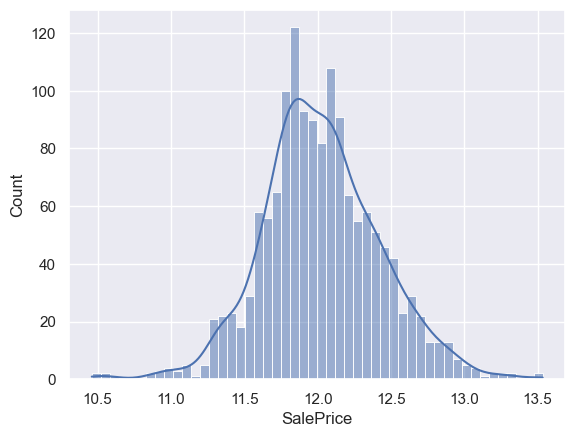

In [ ]:
sns.histplot(
    np.log1p(train_data['SalePrice']),
    bins = 50,
    kde = True
)

plt.show()

<Axes: >

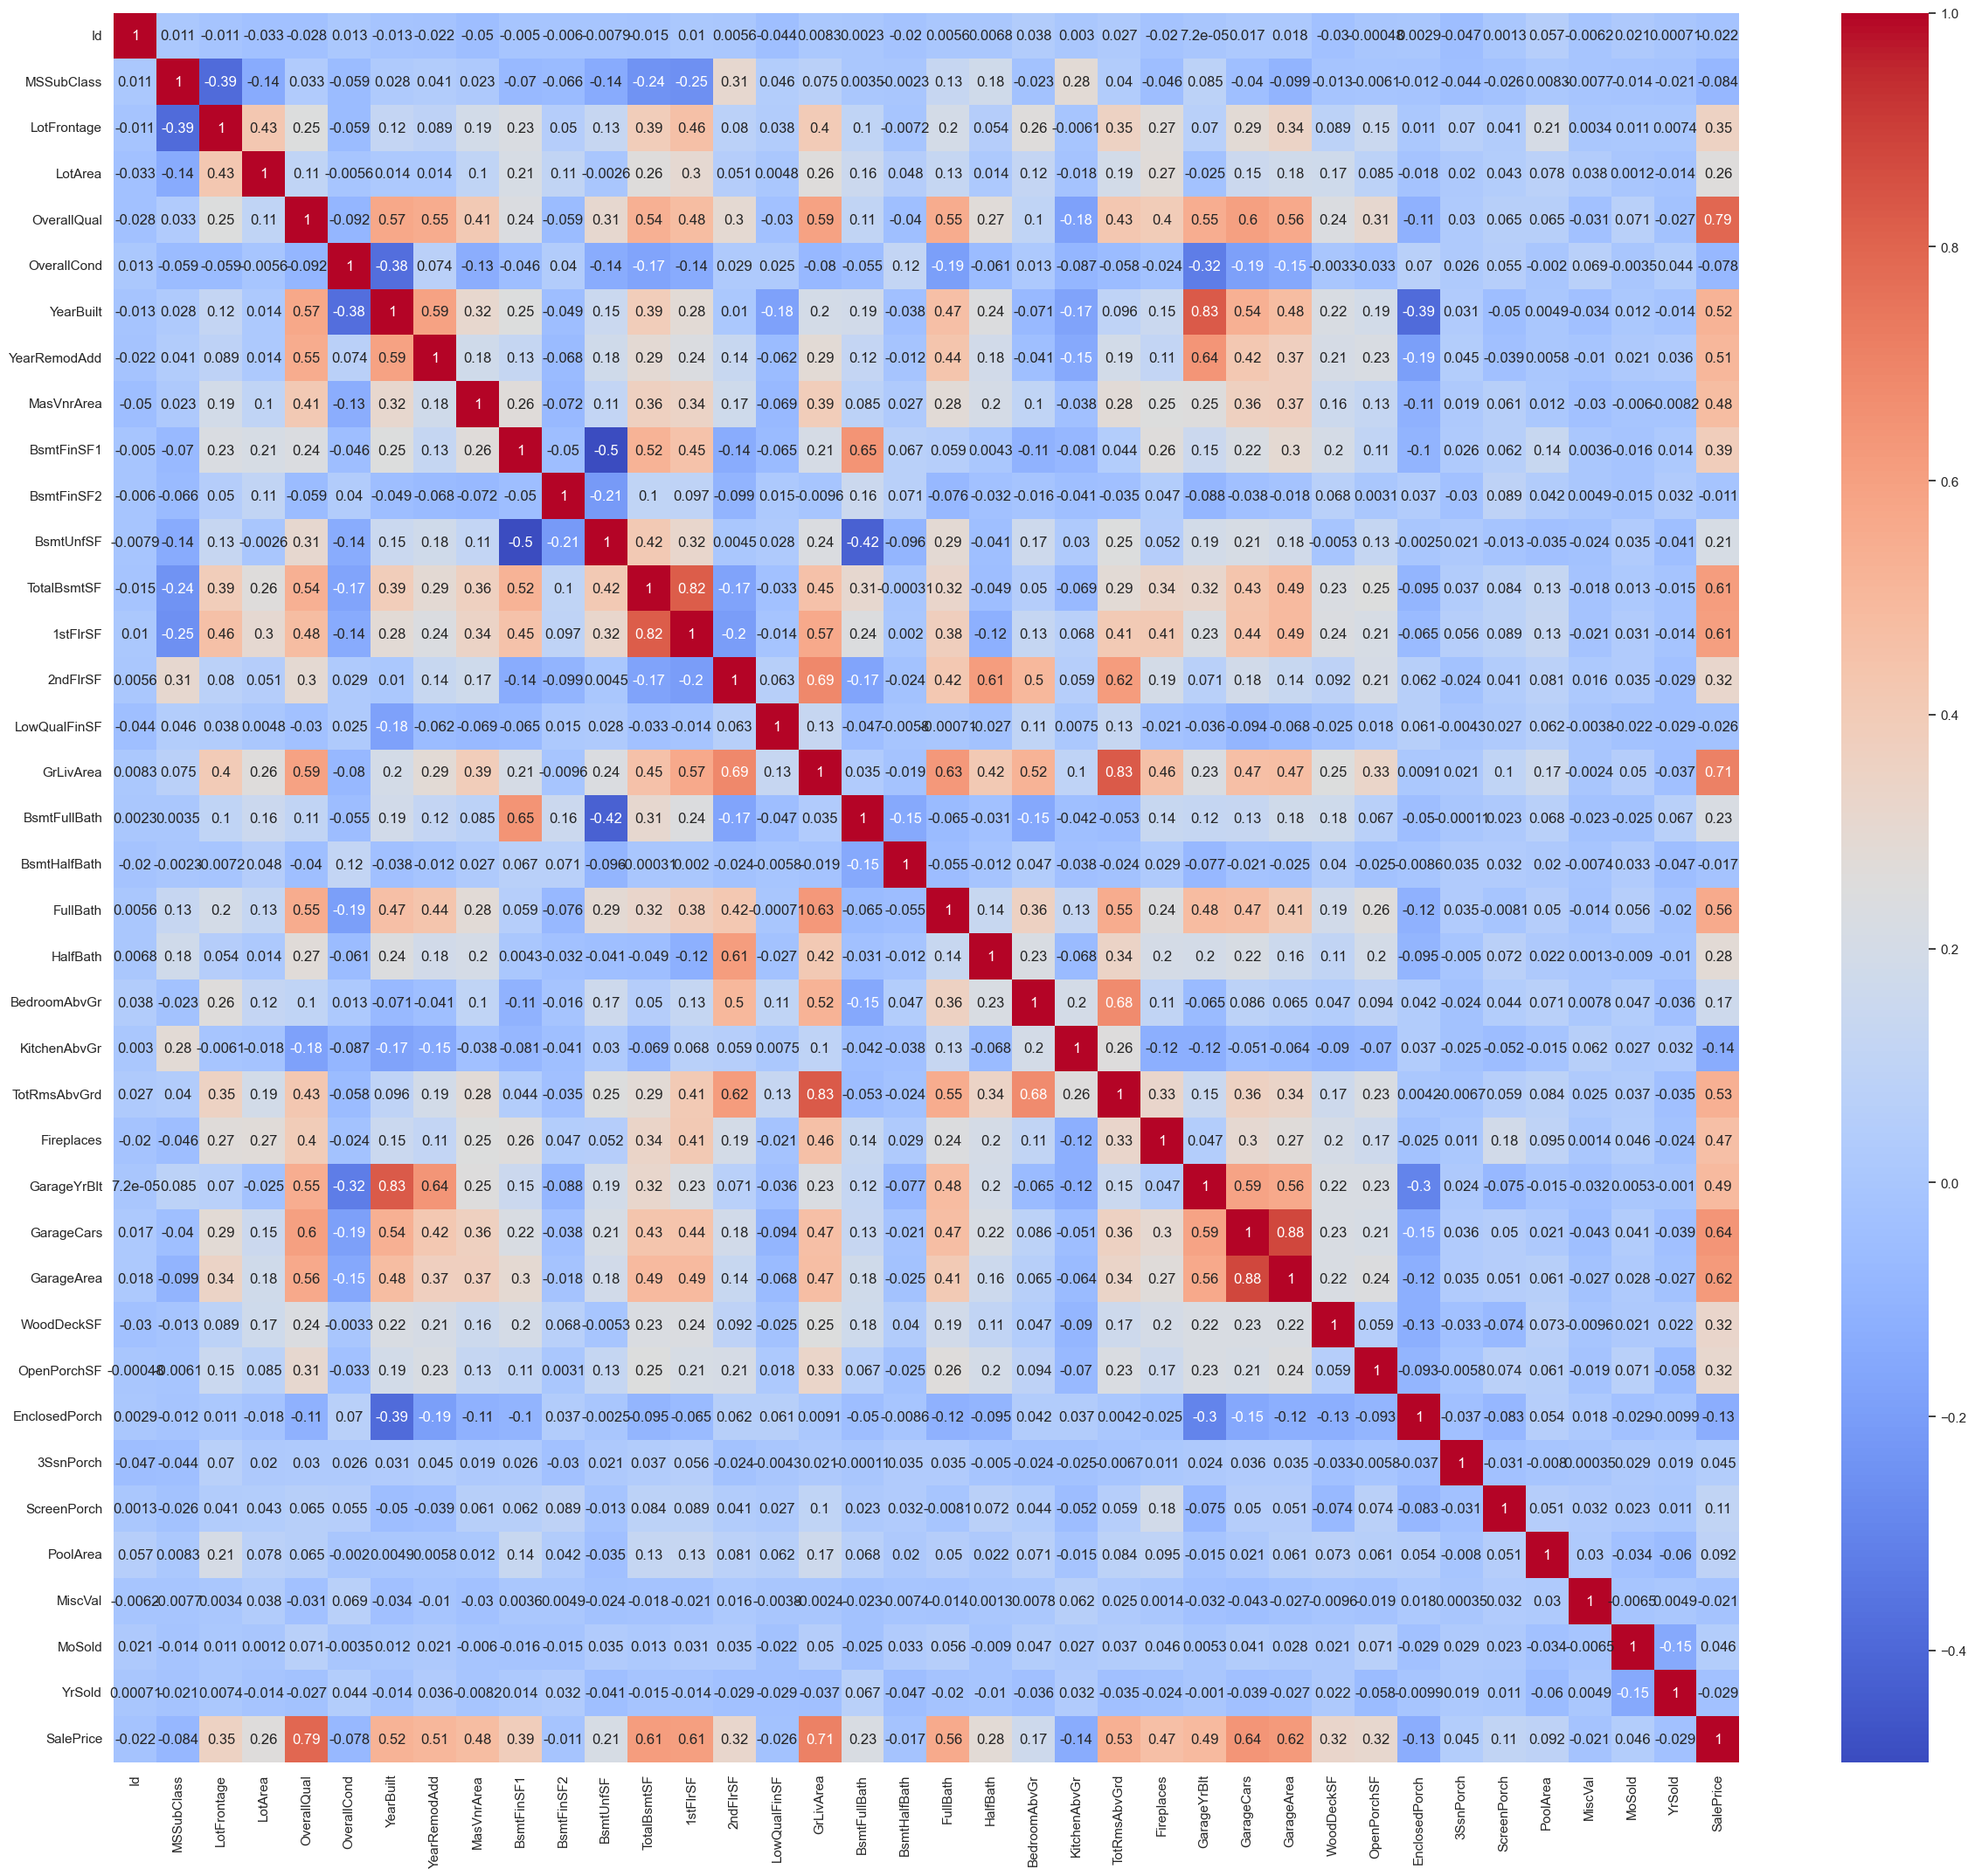

In [121]:
plt.figure(figsize = (30, 26))

sns.heatmap(
    train_data.corr(numeric_only = True),
    annot = True,
    cmap = 'coolwarm'
    )

In [122]:
corr = train_data.corr(numeric_only = True)['SalePrice']
corr.sort_values(ascending = False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

## Missing values Analysis

In [123]:
def missing_values(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * (mis_val / len(df))
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis = 1)

    mis_val_table_ren_col = mis_val_table.rename(
        columns = {0 : 'Missing values', 1 : '% of Total values'})
    mis_val_table_ren_col = mis_val_table_ren_col[
        mis_val_table_ren_col.iloc[:, 1] != 0].sort_values(
            '% of Total values', ascending = False).round(1)
    print('Number is columns in the table: ' + str(df.shape[1]) +
          ('\nNumber is columns is gaps: ') + str(mis_val_table_ren_col.shape[0]))
    return mis_val_table_ren_col

In [124]:
tr = missing_values(train_data)
print(tr)

Number is columns in the table: 81
Number is columns is gaps: 19
              Missing values  % of Total values
PoolQC                  1453               99.5
MiscFeature             1406               96.3
Alley                   1369               93.8
Fence                   1179               80.8
MasVnrType               872               59.7
FireplaceQu              690               47.3
LotFrontage              259               17.7
GarageType                81                5.5
GarageYrBlt               81                5.5
GarageFinish              81                5.5
GarageQual                81                5.5
GarageCond                81                5.5
BsmtExposure              38                2.6
BsmtFinType2              38                2.6
BsmtQual                  37                2.5
BsmtCond                  37                2.5
BsmtFinType1              37                2.5
MasVnrArea                 8                0.5
Electrical             

In [125]:
te = missing_values(test_data)
print(te)

Number is columns in the table: 80
Number is columns is gaps: 33
              Missing values  % of Total values
PoolQC                  1456               99.8
MiscFeature             1408               96.5
Alley                   1352               92.7
Fence                   1169               80.1
MasVnrType               894               61.3
FireplaceQu              730               50.0
LotFrontage              227               15.6
GarageQual                78                5.3
GarageCond                78                5.3
GarageYrBlt               78                5.3
GarageFinish              78                5.3
GarageType                76                5.2
BsmtCond                  45                3.1
BsmtQual                  44                3.0
BsmtExposure              44                3.0
BsmtFinType1              42                2.9
BsmtFinType2              42                2.9
MasVnrArea                15                1.0
MSZoning               

## Feature Engineering

### Plan
Feature analysis and defining the further strategy.  
It’s important to remember that a missing value does not always mean lost information.  
In many Ames Housing features, the absence of a value is itself a meaningful signal — it indicates that a particular feature is not present.  
Hypotheses about the usefulness of binary features will be evaluated through feature importance and by comparing model performance.

### 1. Features where missing means “absence of the object”
For these features, NaN indicates that the object does not exist. We either fill missing values with a special category or create a binary indicator.

- **PoolQC** — pool quality.  
  Missing → no pool.  
  *Action:* create a binary feature: `0` – no pool, `1` – has pool (all non‑NaN).  
  *Hypothesis:* The existence of a pool likely affects price more than its quality. Additional features split by quality can be created for testing.

- **MiscFeature** — miscellaneous features not covered by standard categories.  
  Unique house advantages.  
  Missing → no miscellaneous features. Fill with the category `'None'`.

- **Alley** — alley access to the lot.  
  Missing → no alley access. Fill with `'No Alley'` or `'None'`.

- **Fence** — fence quality.  
  Missing → no fence. Fill with `'No Fence'`.

- **FireplaceQu** — fireplace quality and existence.  
  *Action:* create a binary feature: `0` – no fireplace, `1` – has fireplace (all non‑NaN).

### 2. Garage
All missing values in garage-related features indicate that there is no garage. Fill them accordingly.

**Categorical:**
- **GarageType** — garage type / location.  
  Missing → no garage. Fill with `'No Garage'`.

- **GarageFinish** — interior finish of the garage.  
  Missing → no garage. Fill with `'No Garage'`.

- **GarageQual** — garage quality (materials, workmanship).  
  Missing → no garage. Fill with `'Absent'` — this is an evaluative feature.

- **GarageCond** — garage condition.  
  Missing → no garage. Fill with `'Absent'` — evaluative.

**Numerical:**
- **GarageYrBlt** — year the garage was built.  
  Missing → no garage.  
  Possible approaches:
  - fill with 0;
  - fill with the median;
  - create an additional binary feature `HasGarage`.

- **GarageCars** — garage capacity (number of cars).  
  Missing → no garage. Fill with `0`.

- **GarageArea** — garage area.  
  Missing → no garage. Fill with `0`.

### 3. Basement
Similarly: missing means there is no basement.

**Categorical:**
- **BsmtExposure** — basement wall exposure.  
  Missing → no basement. Fill with `'No Basement'`.

- **BsmtFinType1** — type of finished living area in the basement (primary).  
  Missing → no basement. Fill with `'No Basement'`.

- **BsmtFinType2** — type of finished living area in the basement (secondary).  
  Missing → no basement. Fill with `'No Basement'`.

- **BsmtQual** — basement quality.  
  Missing → no basement. Fill with `'Absent'` — evaluative.

- **BsmtCond** — basement condition.  
  Missing → no basement. Fill with `'Absent'` — evaluative.

**Numerical:**
- **BsmtFinSF1** — finished basement living area (type 1).  
  Missing → no basement. Fill with `0`.

- **BsmtFinSF2** — finished basement living area (type 2).  
  Missing → no basement. Fill with `0`.

- **BsmtUnfSF** — unfinished basement area.  
  Missing → no basement. Fill with `0`.

- **TotalBsmtSF** — total basement area.  
  Missing → no basement. Fill with `0`.

- **BsmtFullBath** — number of full bathrooms in the basement.  
  Missing → no basement. Fill with `0`.

- **BsmtHalfBath** — number of half bathrooms in the basement.  
  Missing → no basement. Fill with `0`.

### 4. Masonry Veneer
- **MasVnrType** — type of masonry veneer.  
  Missing → no veneer. Fill with `'None'`.

- **MasVnrArea** — area of masonry veneer.  
  Missing (and zero values) → no veneer.  
  *Action:* fill missing values with `0`.  
  *Additional check:* consistency between `MasVnrType` and `MasVnrArea` must be verified.

### 5. Categorical features to fill with the mode
- **Electrical** — electrical system type.  
  Only a few missing values; fill with the most frequent category (mode).

- **MSZoning** — zoning classification.

- **Functional** — home functionality.

- **Utilities** — available utilities (if not all `'AllPub'`, may be dropped after inspection).

- **KitchenQual** — kitchen quality. Fill with `'Absent'` — evaluative.

- **Exterior1st** — primary exterior covering material.

- **Exterior2nd** — secondary exterior covering material.

- **SaleType** — type of sale.

### 6. Numerical feature to fill with the median
- **LotFrontage** — length of the lot along the street.  
  Fill missing values with the median (grouping by neighborhood can improve accuracy).

In [ ]:
# Consistency check between MasVnrType and MasVnrArea

type_without_area = train_data[
    (train_data['MasVnrType'] != 'None') &
    (train_data['MasVnrArea'] == 0)
    ]
area_without_type = train_data[
    (train_data['MasVnrType'] == 'None') &
    (train_data['MasVnrArea'] > 0)
]

print(type_without_area.shape, type_without_area[['MasVnrType', 'MasVnrArea']])

(861, 81)      MasVnrType  MasVnrArea
1           NaN         0.0
3           NaN         0.0
5           NaN         0.0
8           NaN         0.0
9           NaN         0.0
10          NaN         0.0
12          NaN         0.0
15          NaN         0.0
17          NaN         0.0
18          NaN         0.0
19          NaN         0.0
21          NaN         0.0
23          NaN         0.0
24          NaN         0.0
26          NaN         0.0
28          NaN         0.0
29          NaN         0.0
30          NaN         0.0
31          NaN         0.0
32          NaN         0.0
33          NaN         0.0
36          NaN         0.0
38          NaN         0.0
39          NaN         0.0
41          NaN         0.0
42          NaN         0.0
43          NaN         0.0
44          NaN         0.0
46          NaN         0.0
47          NaN         0.0
48          NaN         0.0
49          NaN         0.0
50          NaN         0.0
51          NaN         0.0
52        

In [127]:
print(area_without_type.shape, area_without_type[['MasVnrType', 'MasVnrArea']])

(0, 81) Empty DataFrame
Columns: [MasVnrType, MasVnrArea]
Index: []


In [ ]:
# Prepare feature columns and drop the ones not needed at this stage.

for dataset in [train_data, test_data]:

    # Binary fetures
    dataset['HasPool'] = dataset['PoolQC'].notna().astype(int)
    dataset['HasFireplace'] = dataset['FireplaceQu'].notna().astype(int)
    dataset['Remodeled'] = (dataset['YearBuilt'] != dataset['YearRemodAdd']).astype(int)
    dataset['CentralAir'] = dataset['CentralAir'].map({'Y' : 1, 'N' : 0})

    # Categorical missing fetures
    dataset['Fence'] = dataset['Fence'].fillna('No Fence')
    dataset['Alley'] = dataset['Alley'].fillna('No Alley')
    dataset['MiscFeature'] = dataset['MiscFeature'].fillna('No MiscFeature')

    dataset['GarageAge'] = np.where(
        dataset['GarageYrBlt'].notna(),
        dataset['YrSold'] - dataset['GarageYrBlt'],
        -1)
    dataset['GarageType'] = dataset['GarageType'].fillna('No Garage')
    dataset['HasGarage'] = dataset['GarageType'].ne('No Garage').astype(int)
    dataset['GarageFinish'] = dataset['GarageFinish'].fillna('No Garage')
    dataset['GarageQual'] = dataset['GarageQual'].fillna('Absent')
    dataset['GarageCond'] = dataset['GarageCond'].fillna('Absent')
    dataset['MSZoning'] = dataset['MSZoning'].\
        fillna(dataset['MSZoning'].mode()[0])
    dataset['Functional'] = dataset['Functional'].\
        fillna(dataset['Functional'].mode()[0])
    dataset['KitchenQual'] = dataset['KitchenQual'].\
        fillna(dataset['KitchenQual'].mode()[0])
    dataset['SaleType'] = dataset['SaleType'].\
        fillna(dataset['SaleType'].mode()[0])
    dataset['Exterior1st'] = dataset['Exterior1st'].\
        fillna(dataset['Exterior1st'].mode()[0])
    dataset['Exterior2nd'] = dataset['Exterior2nd'].\
        fillna(dataset['Exterior2nd'].mode()[0])

    dataset['BsmtExposure'] = dataset['BsmtExposure'].fillna('No Basement')
    dataset['BsmtFinType1'] = dataset['BsmtFinType1'].fillna('No Basement')
    dataset['BsmtFinType2'] = dataset['BsmtFinType2'].fillna('No Basement')
    dataset['BsmtQual'] = dataset['BsmtQual'].fillna('Absent')
    dataset['BsmtCond'] = dataset['BsmtCond'].fillna('Absent')


    dataset['MasVnrType'] = dataset['MasVnrType'].fillna('None')
    
    # Numerical missing values
    dataset['BsmtFinSF1'] = dataset['BsmtFinSF1'].fillna(0)
    dataset['BsmtFinSF2'] = dataset['BsmtFinSF2'].fillna(0)
    dataset['BsmtUnfSF'] = dataset['BsmtUnfSF'].fillna(0)
    dataset['TotalBsmtSF'] = dataset['TotalBsmtSF'].fillna(0)
    dataset['BsmtFullBath'] = dataset['BsmtFullBath'].fillna(0)
    dataset['BsmtHalfBath'] = dataset['BsmtHalfBath'].fillna(0)

    dataset['GarageCars'] = dataset['GarageCars'].fillna(0)
    dataset['GarageArea'] = dataset['GarageArea'].fillna(0)
    dataset['GarageYrBlt'] = dataset['GarageYrBlt'].fillna(dataset['YearBuilt']).astype(int)
    dataset.loc[(dataset['MasVnrArea'] == 0) &
                (dataset['MasVnrType'] != 'None'),
                'MasVnrType'] = 'None'
    dataset['MasVnrArea'] = dataset['MasVnrArea'].fillna(0)    # No veneer (MasVnrType is None) means zero veneer area (MasVnrArea = 0).
    dataset['Electrical'] = dataset['Electrical'].\
        fillna(dataset['Electrical'].mode()[0])
    dataset['LotFrontage'] = dataset.groupby('Neighborhood')['LotFrontage'].\
        transform(lambda x: x.fillna(x.median()))
    dataset['LotFrontage'] = dataset['LotFrontage'].\
        fillna(dataset['LotFrontage'].median())
    
    # Fill missing masonry type for houses
    # where masonry area exists.
    # Use most frequent masonry category.
    mas_mode = dataset.loc[
        dataset['MasVnrType'] != 'None',
        'MasVnrType'].mode()[0]    
    dataset.loc[(dataset['MasVnrType'] == 'None') &
                (dataset['MasVnrArea'] > 0),
                'MasVnrType'] = mas_mode
    
    dataset['HouseAge'] = dataset['YrSold'] - dataset['YearBuilt']
    dataset['RemodAge'] = dataset['YrSold'] - dataset['YearRemodAdd']
    dataset['TotalBath'] = dataset['FullBath'] + (0.5 * dataset['HalfBath'])

    dataset.drop(['Utilities', 'Alley'], axis = 1, inplace = True)

In [129]:
train_data.drop(['Id'], axis = 1, inplace = True)

In [130]:
train_data['HasGarage'].unique()

array([1, 0])

In [131]:
missing_values(train_data)

Number is columns in the table: 86
Number is columns is gaps: 2


,Missing values,% of Total values
PoolQC,1453,99.5
FireplaceQu,690,47.3


In [132]:
missing_values(test_data)

Number is columns in the table: 86
Number is columns is gaps: 2


,Missing values,% of Total values
PoolQC,1456,99.8
FireplaceQu,730,50.0


In [133]:
train_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HasPool,HasFireplace,Remodeled,GarageAge,HasGarage,HouseAge,RemodAge,TotalBath
0,60,RL,65.0,8450,Pave,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,1,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,No Fence,No MiscFeature,0,2,2008,WD,Normal,208500,0,0,0,5.0,1,5,5,2.5
1,20,RL,80.0,9600,Pave,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,1,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,No Fence,No MiscFeature,0,5,2007,WD,Normal,181500,0,1,0,31.0,1,31,31,2.0
2,60,RL,68.0,11250,Pave,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,1,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,No Fence,No MiscFeature,0,9,2008,WD,Normal,223500,0,1,1,7.0,1,7,6,2.5
3,70,RL,60.0,9550,Pave,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,1,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,No Fence,No MiscFeature,0,2,2006,WD,Abnorml,140000,0,1,1,8.0,1,91,36,1.0
4,60,RL,84.0,14260,Pave,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,1,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,No Fence,No MiscFeature,0,12,2008,WD,Normal,250000,0,1,0,8.0,1,8,8,2.5


### Remaining Features
These variables contain no missing values. The main work involves scaling, grouping rare categories, and creating derived features.

### Lot and Location Characteristics
- **MSSubClass** — building type (encoded as a number: 1‑story, 2‑story, duplex, etc.).
- **LotArea** — lot size in square feet.  
  *Hypothesis:* apply a log transform to improve linearity.
- **Street** — type of road (Grvl – gravel, Pave – paved).
- **LotShape** — general shape of the property (Regular, IR1–IR3).
- **LandContour** — flatness of the property (level, banked, hillside, etc.).
- **LotConfig** — lot configuration (corner, inside, etc.).
- **LandSlope** — slope of the property (Gentle, Moderate, Severe).
- **Neighborhood** — physical location within Ames city limits (25 values). An important spatial feature.
- **Condition1**, **Condition2** — proximity to various conditions (Artery, Feedr, Norm, PosN, RRA…).

### General Building Characteristics
- **BldgType** — type of dwelling (1Fam, 2FmCon, Duplex, TwnhsE, Twnhs).
- **HouseStyle** — style of dwelling (1Story, 2Story, SFoyer…).
- **OverallQual** — overall material and finish quality (1–10). A key predictor.
- **OverallCond** — overall condition rating (1–10).  
  *Hypothesis:* interaction `OverallQual * OverallCond`.
- **YearBuilt** — original construction year.  
  *Hypothesis:* house age (`YrSold – YearBuilt`), binary indicator “built after 2000”.
- **YearRemodAdd** — remodel year (same as YearBuilt if no remodeling).  
  *Hypothesis:* time since remodeling, indicator “was remodeled”.
- **Foundation** — type of foundation (PConc, CBlock, BrkTil, Slab…).

### Exterior Quality and Material
- **ExterQual** — exterior material quality (Ex, Gd, TA, Fa, Po).
- **ExterCond** — present condition of the material on the exterior (same scale).

### Living Area and Rooms
- **1stFlrSF**, **2ndFlrSF** — first and second floor square footage.  
  *Hypothesis:* total above‑ground living area may be a better predictor because price is evaluated per square foot.
- **LowQualFinSF** — low‑quality finished square feet (usually 0).
- **GrLivArea** — above‑grade (ground) living area.  
  *Important:* check for outliers (large area but low price).
- **FullBath**, **HalfBath** — full and half bathrooms above grade.  
  *Hypothesis:* these features describe the overall bathroom provision. Consider creating `TotalBath = FullBath + 0.5 * HalfBath` and compare its predictive power with the raw features via correlation and feature importance.
- **BedroomAbvGr** — bedrooms above grade.
- **KitchenAbvGr** — kitchens above grade (almost always 1).
- **TotRmsAbvGrd** — total rooms above grade (excluding bathrooms).

### Heating and Air Conditioning
- **Heating** — type of heating (GasA, GasW, Grav, Wall…). Rare categories can be grouped.
- **HeatingQC** — heating quality and condition (Ex, Gd, TA, Fa, Po).
- **CentralAir** — central air conditioning (Y/N).
- **Electrical** — electrical system type (no missing values in the test set).

### Roof
- **RoofStyle** — type of roof (Gable, Hip, Gambrel, Flat…).
- **RoofMatl** — roof material (CompShg dominates; class imbalance likely).

### Porches and Outdoor Areas
- **WoodDeckSF** — wood deck area in square feet.
- **OpenPorchSF** — open porch area.
- **EnclosedPorch** — enclosed porch area.
- **3SsnPorch** — three‑season porch area.
- **ScreenPorch** — screen porch area.  
  *Hypothesis:* sum them into `TotalPorchSF` and/or create a binary indicator for the presence of any porch.

### Miscellaneous Numerical and Temporal
- **Fireplaces** — number of fireplaces.
- **PoolArea** — pool area in square feet (almost always 0).
- **MiscVal** — value of miscellaneous features ($).
- **PavedDrive** — paved driveway type (Paved, Partial, Dirt).
- **MoSold** — month sold (1–12).
- **YrSold** — year sold.  
  *Hypothesis:* seasonality, price trend over years.
- **SaleCondition** — condition of sale (Normal, Partial, Abnormal…).

In [134]:
def outliers (df, columns):
    print(df[columns].describe(
        percentiles = [0.005, 0.01, 0.1, 0.90, 0.95, 0.99, 0.995]))
    display(df.nlargest(10, columns)[[columns, 'SalePrice', 'Neighborhood', 'OverallQual']])

### **Outlier detection:**
``Identify houses whose sale price is unusually high or low given their overall characteristics.``

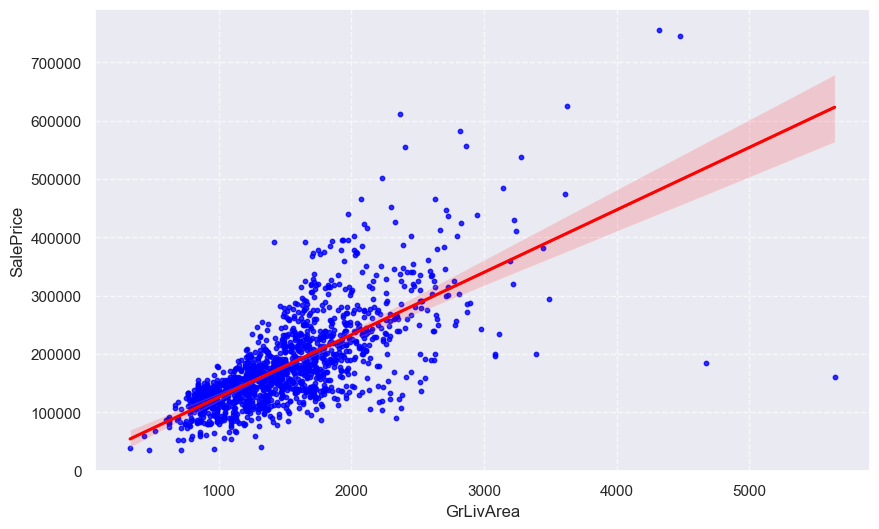

In [135]:
plt.figure(figsize = (10, 6))

sns.regplot(
    data = train_data,
    x = 'GrLivArea',
    y = 'SalePrice',
    scatter_kws = {'s' : 10, 'color' : 'blue'},
    line_kws = {'color' : 'red'})

plt.grid(True, linestyle = '--', alpha = 0.7)
plt.show()

In [136]:
outliers(train_data, 'GrLivArea')

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
0.5%      630.000000
1%        692.180000
10%       912.000000
50%      1464.000000
90%      2158.300000
95%      2466.100000
99%      3123.480000
99.5%    3431.660000
max      5642.000000
Name: GrLivArea, dtype: float64


,GrLivArea,SalePrice,Neighborhood,OverallQual
1298,5642,160000,Edwards,10
523,4676,184750,Edwards,10
1182,4476,745000,NoRidge,10
691,4316,755000,NoRidge,10
1169,3627,625000,NoRidge,10
185,3608,475000,OldTown,10
304,3493,295000,OldTown,7
1268,3447,381000,Crawfor,8
635,3395,200000,SWISU,6
769,3279,538000,StoneBr,8


In [137]:
outliers(train_data[train_data['Neighborhood'] == 'Edwards'], 'GrLivArea')

count     100.00000
mean     1340.04000
std       655.20992
min       605.00000
0.5%      638.16500
1%        671.33000
10%       863.70000
50%      1200.00000
90%      1717.70000
95%      2110.50000
99%      4685.66000
99.5%    5163.83000
max      5642.00000
Name: GrLivArea, dtype: float64


,GrLivArea,SalePrice,Neighborhood,OverallQual
1298,5642,160000,Edwards,10
523,4676,184750,Edwards,10
1423,2201,274970,Edwards,6
921,2200,145900,Edwards,5
175,2158,243000,Edwards,6
1168,2108,235000,Edwards,6
607,2008,225000,Edwards,5
362,1922,198500,Edwards,7
110,1855,136900,Edwards,6
1045,1733,139600,Edwards,3


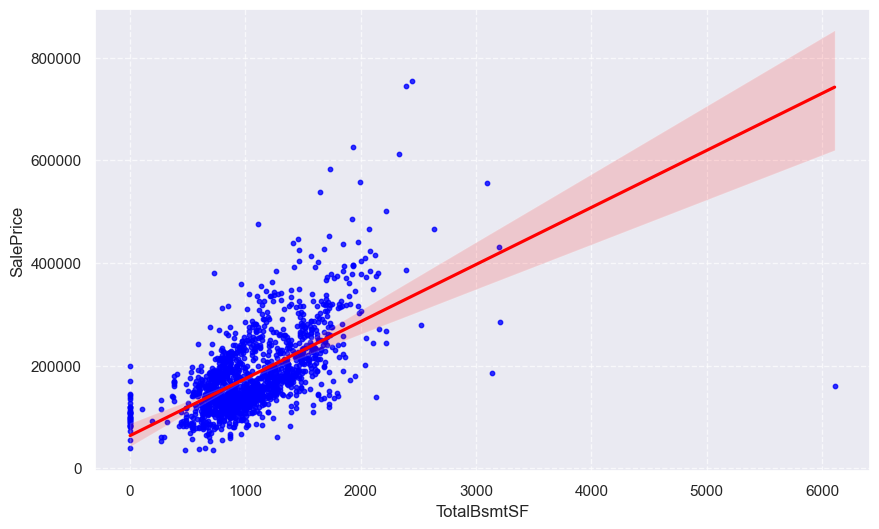

In [138]:
plt.figure(figsize = (10, 6))

sns.regplot(
    data = train_data,
    x = 'TotalBsmtSF',
    y = 'SalePrice',
    scatter_kws = {'s' : 10, 'color' : 'blue'},
    line_kws = {'color' : 'red'}
)

plt.grid(True, linestyle = '--', alpha = 0.7)
plt.show()

In [139]:
outliers(train_data, 'TotalBsmtSF')

count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
0.5%        0.000000
1%          0.000000
10%       636.900000
50%       991.500000
90%      1602.200000
95%      1753.000000
99%      2155.050000
99.5%    2429.840000
max      6110.000000
Name: TotalBsmtSF, dtype: float64


,TotalBsmtSF,SalePrice,Neighborhood,OverallQual
1298,6110,160000,Edwards,10
332,3206,284000,NridgHt,8
496,3200,430000,NoRidge,8
523,3138,184750,Edwards,10
440,3094,555000,NridgHt,10
1373,2633,466500,NoRidge,10
1044,2524,278000,NWAmes,8
691,2444,755000,NoRidge,10
1182,2396,745000,NoRidge,10
224,2392,386250,NridgHt,10


In [140]:
train_data[(train_data['TotalBsmtSF'] > 3000)]\
[['TotalBsmtSF',
'Neighborhood',
'SalePrice',
'OverallQual']]

,TotalBsmtSF,Neighborhood,SalePrice,OverallQual
332,3206,NridgHt,284000,8
440,3094,NridgHt,555000,10
496,3200,NoRidge,430000,8
523,3138,Edwards,184750,10
1298,6110,Edwards,160000,10


In [141]:
train_data.drop(train_data[
    (train_data['GrLivArea'] > 4000) &
    (train_data['SalePrice'] < 300000)
    ].index, inplace = True)
train_data.drop(train_data[
    (train_data['TotalBsmtSF'] > 5000) &
    (train_data['SalePrice'] < 300000)
    ].index, inplace = True)

### **Hypothesis:**
``There are outliers in LotArea.``

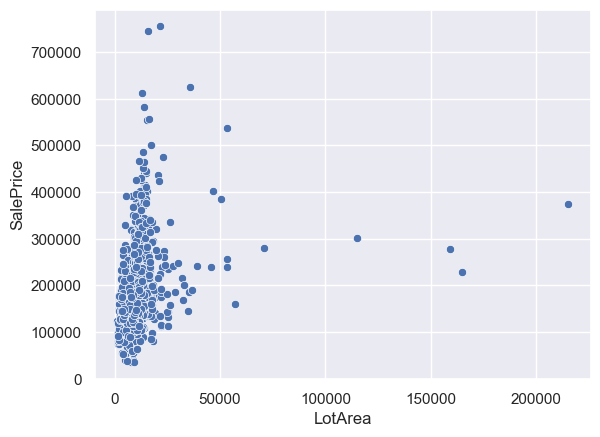

In [142]:
sns.scatterplot(
    data = train_data,
    x = 'LotArea',
    y = 'SalePrice'
)
plt.show()

In [143]:
outliers(train_data, 'LotArea')

count      1458.000000
mean      10459.936900
std        9859.198156
min        1300.000000
0.5%       1680.000000
1%         1680.000000
10%        5000.000000
50%        9475.000000
90%       14340.900000
95%       17151.550000
99%       35402.610000
99.5%     53192.800000
max      215245.000000
Name: LotArea, dtype: float64


,LotArea,SalePrice,Neighborhood,OverallQual
313,215245,375000,Timber,7
335,164660,228950,Timber,5
249,159000,277000,ClearCr,6
706,115149,302000,ClearCr,7
451,70761,280000,ClearCr,7
1396,57200,160000,Timber,5
769,53504,538000,StoneBr,8
457,53227,256000,ClearCr,4
384,53107,240000,ClearCr,6
53,50271,385000,Veenker,9


In [144]:
neighborhood_stats = (
    train_data.groupby('Neighborhood')['SalePrice']\
    .agg(['count', 'mean', 'median'])\
    .sort_values('mean', ascending = False)
)
display(neighborhood_stats)

,count,mean,median
Neighborhood,,,
NoRidge,41,335295.317073,301500.0
NridgHt,77,316270.623377,315000.0
StoneBr,25,310499.000000,278000.0
Timber,38,242247.447368,228475.0
Veenker,11,238772.727273,218000.0
Somerst,86,225379.837209,225500.0
ClearCr,28,212565.428571,200250.0
Crawfor,51,210624.725490,200624.0
CollgCr,150,197965.773333,197200.0


Neighborhood is one of the key factors affecting property value.  
Even with similar house characteristics, neighborhood differences can lead to significant price variation.

- **NridgHt** – One of the most expensive neighborhoods. New, high‑quality homes.
- **NoRidge** – Prestigious area with large, expensive homes.
- **StoneBr** – Elite neighborhood with very expensive properties.
- **Timber** – Area near wooded zones. Large lots and high prices.
- **Veenker** – Small upscale neighborhood, often near golf courses.
- **Somerst** – Modern neighborhood with many newer homes.
- **ClearCr** – Quiet area close to natural spaces.
- **Crawfor** – Older prestigious neighborhood with historic homes.
- **CollgCr** – Popular modern neighborhood. Above‑average prices.
- **Blmngtn** – Contemporary residential development.
- **Gilbert** – New suburban area with average to above‑average home values.
- **NWAmes** – Well‑established suburban neighborhood.
- **SawyerW** – Improved version of Sawyer. Mid‑ to upper‑mid price range.
- **Mitchel** – Typical middle‑class residential area.
- **NAmes** – Most common neighborhood in the dataset. A good benchmark for an “average” home.
- **Blueste** – Very small neighborhood with few observations.
- **Sawyer** – More affordable area.
- **IDOTRR** – Area near railroad and industrial sites. Low prices.
- **BrkSide** – Older residential area with inexpensive homes.
- **Edwards** – Working‑class neighborhood with below‑average prices.
- **OldTown** – Old city center. Many older homes.
- **SWISU** – Area near Iowa State University.
- **MeadowV** – One of the most affordable neighborhoods in the dataset.
- **BrDale** – Small neighborhood with relatively low‑cost housing.
- **NPkVill** – Compact development, townhouses, low prices.

In [145]:
train_data.nlargest(10, 'LotArea')\
[['LotArea',
'Neighborhood',
'SalePrice',
'OverallQual',
'GrLivArea']]

,LotArea,Neighborhood,SalePrice,OverallQual,GrLivArea
313,215245,Timber,375000,7,2036
335,164660,Timber,228950,5,1786
249,159000,ClearCr,277000,6,2144
706,115149,ClearCr,302000,7,1824
451,70761,ClearCr,280000,7,1533
1396,57200,Timber,160000,5,1687
769,53504,StoneBr,538000,8,3279
457,53227,ClearCr,256000,4,1663
384,53107,ClearCr,240000,6,1953
53,50271,Veenker,385000,9,1842


In [146]:
train_data[train_data['Neighborhood'] == 'Timber'].nlargest(10, 'LotArea')\
[['LotArea',
'Neighborhood',
'SalePrice',
'OverallQual',
'GrLivArea']]

,LotArea,Neighborhood,SalePrice,OverallQual,GrLivArea
313,215245,Timber,375000,7,2036
335,164660,Timber,228950,5,1786
1396,57200,Timber,160000,5,1687
1184,35133,Timber,186700,5,1572
692,26178,Timber,335000,7,2519
41,16905,Timber,170000,5,1328
169,16669,Timber,228000,8,1707
1024,15498,Timber,287000,8,2898
1347,15306,Timber,283463,8,1776
540,14601,Timber,315000,9,1838


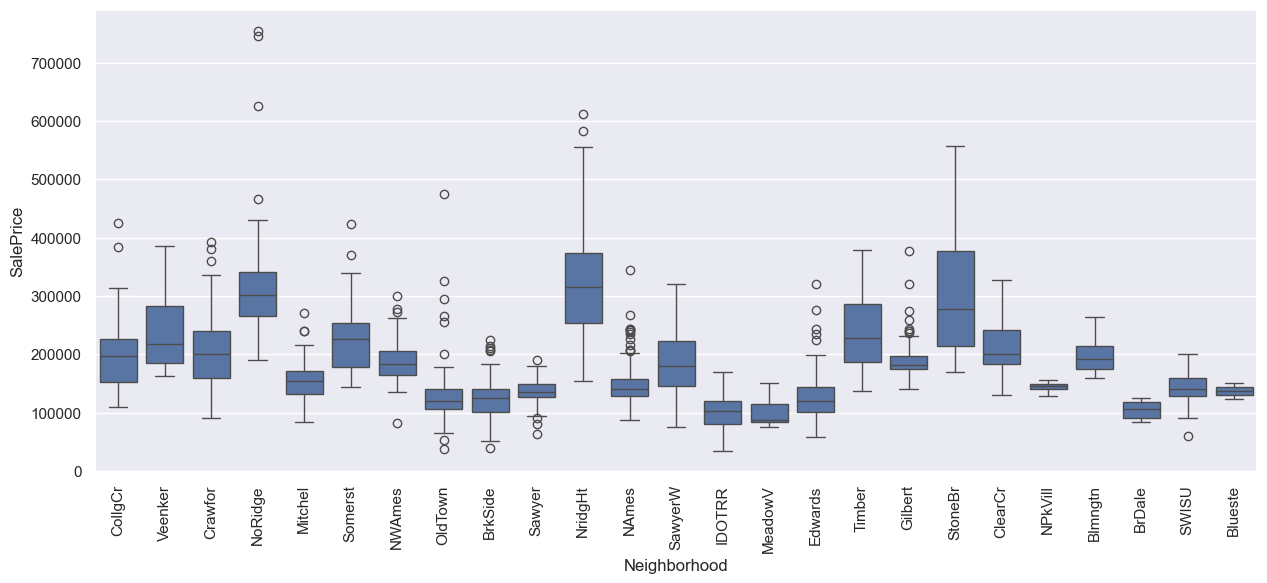

In [147]:
plt.figure(figsize = (15, 6))

sns.boxplot(
    data = train_data,
    x = 'Neighborhood',
    y = 'SalePrice'
)

plt.xticks(rotation = 90)
plt.show()

**Hypothesis not confirmed.**

Although the LotArea value is extremely large (215,245 sq. ft.), the property is located in the Timber neighborhood, which is known for large lots and high property values.

The sale price is consistent with the neighborhood level and does not deviate from the overall price distribution in Timber.

The data point is not an outlier.

### **Hypothesis:**
``Total square footage is a better predictor of price because home values are evaluated on a per‑square‑foot basis.``

In [148]:
train_data['AllFlr'] = train_data['1stFlrSF'] + train_data['2ndFlrSF']

In [149]:
train_data['AllFlr'].info()

<class 'pandas.core.series.Series'>
Index: 1458 entries, 0 to 1459
Series name: AllFlr
Non-Null Count  Dtype
--------------  -----
1458 non-null   int64
dtypes: int64(1)
memory usage: 22.8 KB


In [150]:
train_data[[
    '1stFlrSF',
    '2ndFlrSF',
    'GrLivArea',
    'AllFlr',
    'SalePrice']].corr()

,1stFlrSF,2ndFlrSF,GrLivArea,AllFlr,SalePrice
1stFlrSF,1.000000,-0.230408,0.533697,0.539816,0.631530
2ndFlrSF,-0.230408,1.000000,0.694678,0.694756,0.320532
GrLivArea,0.533697,0.694678,1.000000,0.995410,0.734968
AllFlr,0.539816,0.694756,0.995410,1.000000,0.744063
SalePrice,0.631530,0.320532,0.734968,0.744063,1.000000


In [151]:
train_data[[
    '1stFlrSF',
    '2ndFlrSF',
    'AllFlr',
    'GrLivArea']].corr()

,1stFlrSF,2ndFlrSF,AllFlr,GrLivArea
1stFlrSF,1.000000,-0.230408,0.539816,0.533697
2ndFlrSF,-0.230408,1.000000,0.694756,0.694678
AllFlr,0.539816,0.694756,1.000000,0.995410
GrLivArea,0.533697,0.694678,0.995410,1.000000


In [152]:
train_data.drop(['AllFlr'], axis = 1, inplace = True)

**Hypothesis confirmed.**

The correlation of `GrLivArea` with the target variable (0.709) is higher than that of the individual floor areas:
- `1stFlrSF`: 0.606
- `2ndFlrSF`: 0.319

This indicates that the total above‑grade living area (`GrLivArea`) reflects property value more effectively than each floor area taken separately. Although the separate floor features do retain information about the existence of a second floor, `GrLivArea` already aggregates the total living space and is more strongly correlated with sale price. The sum of `1stFlrSF` and `2ndFlrSF` is exactly `GrLivArea`, so creating an additional combined feature would be redundant.

At this stage, there is no need to engineer a new feature, as the same information is already captured by `GrLivArea`.

### **Hypothesis:**
``The features `PoolArea` and `HasPool` carry the same information.``

In [153]:
train_data[['HasPool', 'SalePrice']].corr()

,HasPool,SalePrice
HasPool,1.000000,0.103995
SalePrice,0.103995,1.000000


In [154]:
train_data.groupby('HasPool')['SalePrice'].median()

HasPool
0    162900.0
1    242500.0
Name: SalePrice, dtype: float64

**Hypothesis confirmed.**

The features `PoolArea` and `HasPool` carry nearly identical information.

Most houses don’t have a pool, so the pool area is zero in the vast majority of observations.

The correlation of `HasPool` with sale price is 0.094, which is slightly higher than the correlation of `PoolArea`.

To reduce feature redundancy, the binary indicator `HasPool` is retained, capturing the mere fact of having a pool.

### **Hypothesis:**
``A `PoolArea` and `PoolQC` have a weaker influence on price than the mere presence of a pool.``

In [155]:
rating = {
    'Absent' : 0,
    'Po' : 1,
    'Fa' : 2,
    'TA' : 3,
    'Gd' : 4,
    'Ex' : 5
}

In [156]:
train_data['PoolQC'].unique()

array([nan, 'Ex', 'Fa', 'Gd'], dtype=object)

In [157]:
for dataset in [train_data, test_data]:
    dataset['PoolQC'] = dataset['PoolQC'].fillna('Absent')
    dataset['PoolQC'] = dataset['PoolQC'].map(rating)

In [158]:
train_data[[
    'PoolArea',
    'HasPool',
    'PoolQC',
    'SalePrice']].corr()

,PoolArea,HasPool,PoolQC,SalePrice
PoolArea,1.000000,0.991075,0.931972,0.099490
HasPool,0.991075,1.000000,0.946526,0.103995
PoolQC,0.931972,0.946526,1.000000,0.124084
SalePrice,0.099490,0.103995,0.124084,1.000000


**Hypothesis partially confirmed.**

Pool quality has a stronger effect on price than the mere presence of a pool or its size.  
Since `PoolArea` duplicates `HasPool` and may cause overfitting when `PoolQC` is also included, we drop the `PoolArea` feature.

### **Hypothesis:**
``The presence of a garage has a noticeable impact on property value.``

In [159]:
train_data[['HasGarage', 'SalePrice']].corr()

,HasGarage,SalePrice
HasGarage,1.000000,0.236883
SalePrice,0.236883,1.000000


In [160]:
train_data.groupby('HasGarage')['SalePrice'].median()

HasGarage
0    100000.0
1    167500.0
Name: SalePrice, dtype: float64

**Hypothesis confirmed.**

The median price of houses without a garage is around $100,000, while for houses with a garage the median price reaches $167,500.

The correlation of the `HasGarage` feature with the target variable is 0.237.

The feature is retained for further modeling.

### **Hypotheses:**
``Fireplaces and HasFireplace carry the same information.``

``FireplaceQu has a significant effect on price.``

In [161]:
train_data['FireplaceQu'].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [162]:
for dataset in [train_data, test_data]:
    dataset['FireplaceQu'] = (dataset['FireplaceQu'].fillna('Absent')).map(rating)

In [163]:
train_data[['Fireplaces', 'HasFireplace', 'FireplaceQu', 'SalePrice']].corr()

,Fireplaces,HasFireplace,FireplaceQu,SalePrice
Fireplaces,1.000000,0.902581,0.864730,0.469862
HasFireplace,0.902581,1.000000,0.954488,0.472350
FireplaceQu,0.864730,0.954488,1.000000,0.521144
SalePrice,0.469862,0.472350,0.521144,1.000000


In [164]:
train_data['Fireplaces'].unique()

array([0, 1, 2, 3])

In [165]:
train_data.groupby('Fireplaces')['SalePrice'].median()

Fireplaces
0    135000.0
1    190000.0
2    206900.0
3    275000.0
Name: SalePrice, dtype: float64

In [166]:
train_data.groupby('FireplaceQu')['SalePrice'].median()

FireplaceQu
0    135000.0
1    131500.0
2    158000.0
3    187500.0
4    207000.0
5    314250.0
Name: SalePrice, dtype: float64

**Hypothesis partially confirmed.**

The number of fireplaces (`Fireplaces`) and the binary indicator of fireplace presence (`HasFireplace`) show nearly identical relationships with sale price.

The correlation of `HasFireplace` (0.472) is slightly higher than that of `Fireplaces` (0.467). However, `FireplaceQu` has an even higher correlation and captures a wider range of price variation.

Because these features carry overlapping information and are highly correlated with each other (0.90), we retain `Fireplaces` and `FireplaceQu` to reduce redundancy. Analysis of median sale prices shows a clear increase in price with more fireplaces. `Fireplaces` and `FireplaceQu` contain additional information about the property that would be lost if only the binary indicator were used.

### **Hypothesis:**
``Combining `FullBath` and `HalfBath` into a single `TotalBath` feature will have a stronger influence on the target variable than either feature alone.``

In [167]:
train_data[['FullBath', 'HalfBath', 'TotalBath', 'SalePrice']].corr()

,FullBath,HalfBath,TotalBath,SalePrice
FullBath,1.000000,0.134001,0.919723,0.562165
HalfBath,0.134001,1.000000,0.512271,0.284590
TotalBath,0.919723,0.512271,1.000000,0.599932
SalePrice,0.562165,0.284590,0.599932,1.000000


In [168]:
train_data['HalfBath'].unique()

array([1, 0, 2])

**Hypothesis confirmed.**

The engineered feature `TotalBath` showed a higher correlation with the target variable (0.598) than the original features `FullBath` (0.561) and `HalfBath` (0.284).

This suggests that a combined measure of bathroom provision better captures property value.

In the next step, the impact of removing the original features `FullBath` and `HalfBath` will be evaluated through model performance.

### **Hypothesis:**
``House age, garage age, and time since last remodel influence the sale price.``

In [169]:
train_data\
[['HouseAge',
  'GarageAge',
  'RemodAge',
  'SalePrice']].corr()

,HouseAge,GarageAge,RemodAge,SalePrice
HouseAge,1.000000,0.685479,0.593432,-0.524067
GarageAge,0.685479,1.000000,0.561876,-0.387162
RemodAge,0.593432,0.561876,1.000000,-0.509706
SalePrice,-0.524067,-0.387162,-0.509706,1.000000


**Hypothesis partially confirmed.**

All three age-related features show a weak negative correlation with price (–0.23, –0.06, –0.16). `HouseAge` and `RemodAge` are slightly more informative, but none of them is a strong predictor on its own. The features are retained because they may be useful in interactions with other variables (e.g., age × neighborhood).

### **Hypothesis:**
``Summing the individual porch area features into a single `TotalPorchSF` feature will produce a stronger predictor of sale price.``

In [170]:
train_data['TotalPorchSF'] = (
    train_data['WoodDeckSF'] +
    train_data['OpenPorchSF'] +
    train_data['EnclosedPorch'] +
    train_data['3SsnPorch'] +
    train_data['ScreenPorch'])

In [171]:
train_data['TotalPorchSF'].describe()

count    1458.000000
mean      180.810014
std       156.120838
min         0.000000
25%        45.000000
50%       164.000000
75%       265.000000
max      1027.000000
Name: TotalPorchSF, dtype: float64

In [172]:
train_data\
[['TotalPorchSF',
'WoodDeckSF',
'OpenPorchSF',
'EnclosedPorch',
'3SsnPorch',
'ScreenPorch',
'SalePrice']].corr()

,TotalPorchSF,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,SalePrice
TotalPorchSF,1.000000,0.743620,0.451927,0.215599,0.133646,0.291892,0.392897
WoodDeckSF,0.743620,1.000000,0.053686,-0.125616,-0.032642,-0.073884,0.324758
OpenPorchSF,0.451927,0.053686,1.000000,-0.092212,-0.005191,0.077150,0.321142
EnclosedPorch,0.215599,-0.125616,-0.092212,1.000000,-0.037366,-0.083009,-0.128646
3SsnPorch,0.133646,-0.032642,-0.005191,-0.037366,1.000000,-0.031481,0.044568
ScreenPorch,0.291892,-0.073884,0.077150,-0.083009,-0.031481,1.000000,0.111415
SalePrice,0.392897,0.324758,0.321142,-0.128646,0.044568,0.111415,1.000000


In [173]:
train_data.drop(['TotalPorchSF'], axis = 1, inplace = True)

In [174]:
for dataset in [train_data, test_data]:
    dataset['TotalPorchSF'] = (
        dataset['WoodDeckSF'] +
        dataset['OpenPorchSF'])

In [175]:
train_data\
[[
    'TotalPorchSF',
    'WoodDeckSF',
    'OpenPorchSF',
    'SalePrice'
]].corr()

,TotalPorchSF,WoodDeckSF,OpenPorchSF,SalePrice
TotalPorchSF,1.000000,0.892227,0.498836,0.427106
WoodDeckSF,0.892227,1.000000,0.053686,0.324758
OpenPorchSF,0.498836,0.053686,1.000000,0.321142
SalePrice,0.427106,0.324758,0.321142,1.000000


**Hypothesis not fully confirmed.**

The combined feature `TotalPorchSF` shows a correlation with price of 0.393, which is only marginally higher than the correlations of the most informative individual features: `WoodDeckSF` (0.325) and `OpenPorchSF` (0.321).

Additionally, it was observed that different porch types affect property value in opposite directions. For example, `EnclosedPorch` shows a negative correlation (–0.129).

This suggests that aggregating all types of outdoor areas into a single feature can lead to a loss of information.

At this stage, the features are kept separate.

### **Hypothesis:**
``Multiplying `OverallQual` and `OverallCond` into a single interaction feature will combine the house’s quality and condition into one integrated metric.``

In [176]:
train_data['OveralScore'] = train_data['OverallQual'] * train_data['OverallCond']

In [177]:
train_data\
[['OveralScore',
'OverallQual',
'OverallCond',
'SalePrice']].corr()

,OveralScore,OverallQual,OverallCond,SalePrice
OveralScore,1.000000,0.715808,0.609361,0.566759
OverallQual,0.715808,1.000000,-0.090442,0.795774
OverallCond,0.609361,-0.090442,1.000000,-0.077948
SalePrice,0.566759,0.795774,-0.077948,1.000000


In [178]:
train_data.drop(['OveralScore'], axis = 1, inplace = True)

**Hypothesis not confirmed.**

The engineered feature `OverallScore` showed a weaker correlation with the target variable (0.567) than the original `OverallQual` feature (0.796).

The likely reason is that `OverallCond` has almost no relationship with sale price (–0.078) and introduces noise when multiplied.

Therefore, `OverallScore` is excluded from further analysis, while `OverallQual` is retained as a more informative predictor of price.

### **Hypothesis:**
``Creating a new binary feature `SpecialCondition` will improve model performance by highlighting atypical sale conditions.``

In [179]:
for dataset in [train_data, test_data]:
    dataset['SpecialCondition'] = (
        (dataset['Condition1'] != 'Norm') |
        (dataset['Condition2'] != 'Norm')
    ).astype(int)

In [180]:
train_data\
[['SpecialCondition',
 'SalePrice']].corr()

,SpecialCondition,SalePrice
SpecialCondition,1.00000,-0.11309
SalePrice,-0.11309,1.00000


In [181]:
train_data.groupby('SpecialCondition')['SalePrice'].median()

SpecialCondition
0    166500.0
1    144000.0
Name: SalePrice, dtype: float64

In [182]:
for dataset in [train_data, test_data]:
    dataset.drop(['SpecialCondition'], axis = 1, inplace = True)

**Hypothesis not confirmed.**

The binary feature `SpecialCondition` loses the information held in the original categorical features. It has a weak positive correlation with price (0.11), even though the median price for houses with a non‑"Norm" sale condition is $21,500 higher than for normal sales. This indicates that while the median difference is notable, the binary feature alone does not capture the relationship strongly enough and discards useful detail from the categories.

### Heatmap Check

In [183]:
for dataset in [train_data, test_data]:

    dataset.drop(['HalfBath', 'FullBath', 'PoolArea', 'HasFireplace', 'TotalPorchSF'],
                  axis = 1, inplace = True )   # Удалить после проверкм влияния на цену


<Axes: >

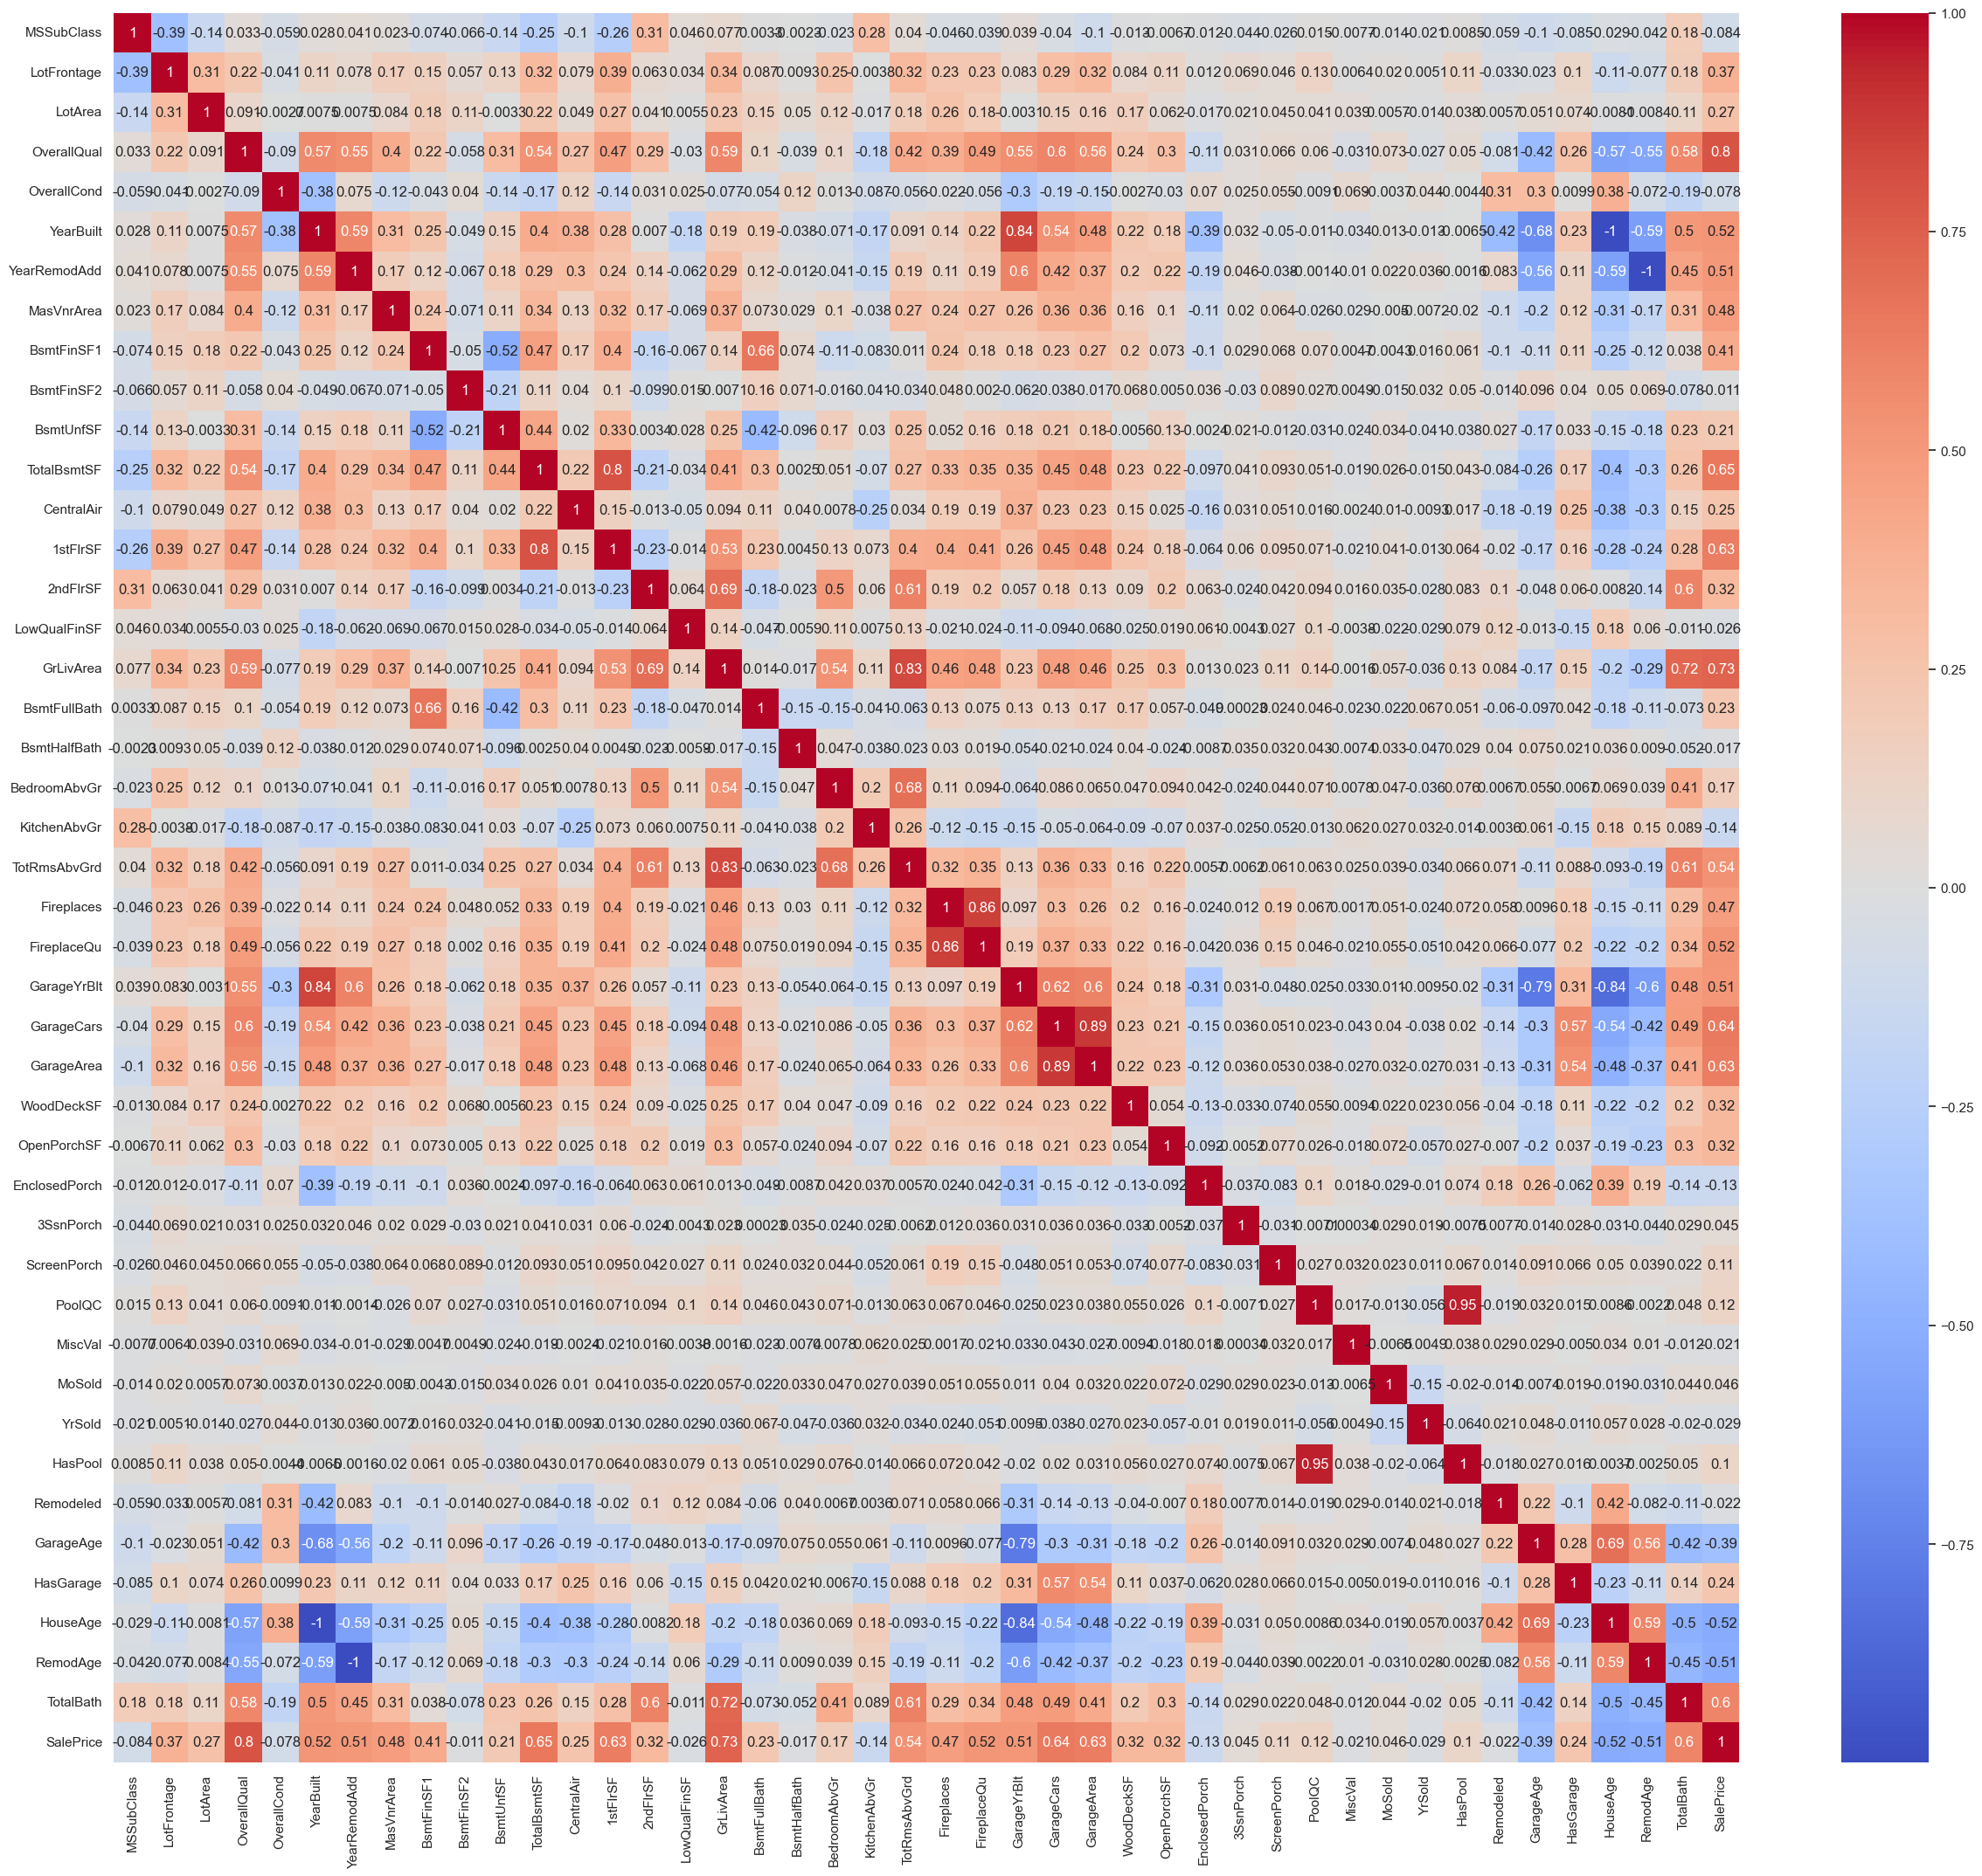

In [184]:
train_data['SalePrice'] = train_data.pop('SalePrice')

plt.figure(figsize = (30, 26))

sns.heatmap(
    train_data.corr(numeric_only = True),
    annot = True,
    cmap = 'coolwarm'
    )

In [185]:
missing_values(train_data)

Number is columns in the table: 82
Number is columns is gaps: 0


,Missing values,% of Total values


In [186]:
missing_values(test_data)

Number is columns in the table: 82
Number is columns is gaps: 0


,Missing values,% of Total values


### Ordinal Encoding

In [187]:
print(train_data['ExterQual'].unique())
print(test_data['ExterQual'].unique())
print(train_data['ExterCond'].unique())
print(test_data['ExterCond'].unique())
print(train_data['KitchenQual'].unique())
print(test_data['KitchenQual'].unique())
print(train_data['GarageQual'].unique())
print(test_data['GarageQual'].unique())
print(train_data['BsmtCond'].unique())
print(test_data['BsmtCond'].unique())
print(train_data['BsmtQual'].unique())
print(test_data['BsmtQual'].unique())
print(train_data['GarageCond'].unique())
print(test_data['GarageCond'].unique())
print(train_data['HeatingQC'].unique())
print(test_data['HeatingQC'].unique())

['Gd' 'TA' 'Ex' 'Fa']
['TA' 'Gd' 'Ex' 'Fa']
['TA' 'Gd' 'Fa' 'Po' 'Ex']
['TA' 'Gd' 'Fa' 'Po' 'Ex']
['Gd' 'TA' 'Ex' 'Fa']
['TA' 'Gd' 'Ex' 'Fa']
['TA' 'Fa' 'Gd' 'Absent' 'Ex' 'Po']
['TA' 'Absent' 'Fa' 'Gd' 'Po']
['TA' 'Gd' 'Absent' 'Fa' 'Po']
['TA' 'Po' 'Fa' 'Gd' 'Absent']
['Gd' 'TA' 'Ex' 'Absent' 'Fa']
['TA' 'Gd' 'Ex' 'Fa' 'Absent']
['TA' 'Fa' 'Absent' 'Gd' 'Po' 'Ex']
['TA' 'Absent' 'Fa' 'Gd' 'Po' 'Ex']
['Ex' 'Gd' 'TA' 'Fa' 'Po']
['TA' 'Gd' 'Ex' 'Fa' 'Po']


In [188]:
for dataset in [train_data, test_data]:
    dataset['ExterCond'] = dataset['ExterCond'].map(rating)
    dataset['ExterQual'] = dataset['ExterQual'].map(rating)
    dataset['KitchenQual'] = dataset['KitchenQual'].map(rating)
    dataset['GarageQual'] = dataset['GarageQual'].map(rating)
    dataset['GarageCond'] = dataset['GarageCond'].map(rating)
    dataset['BsmtCond'] = dataset['BsmtCond'].map(rating)
    dataset['BsmtQual'] = dataset['BsmtQual'].map(rating)
    dataset['HeatingQC'] = dataset['HeatingQC'].map(rating)

In [189]:
train_data[['HasGarage', 'GarageQual', 'GarageCond', 'SalePrice']].corr()

,HasGarage,GarageQual,GarageCond,SalePrice
HasGarage,1.000000,0.942494,0.946240,0.236883
GarageQual,0.942494,1.000000,0.959168,0.273898
GarageCond,0.946240,0.959168,1.000000,0.263249
SalePrice,0.236883,0.273898,0.263249,1.000000


In [190]:
train_data[['BsmtQual', 'BsmtCond', 'TotalBsmtSF', 'SalePrice']].corr()

,BsmtQual,BsmtCond,TotalBsmtSF,SalePrice
BsmtQual,1.000000,0.634737,0.577795,0.586674
BsmtCond,0.634737,1.000000,0.392709,0.212632
TotalBsmtSF,0.577795,0.392709,1.000000,0.651153
SalePrice,0.586674,0.212632,0.651153,1.000000


In [191]:
train_data\
[['ExterQual',
'ExterCond',
'KitchenQual',
'GarageQual',
'GarageCond',
'BsmtQual',
'BsmtCond',
'HeatingQC']].isna().sum()

ExterQual      0
ExterCond      0
KitchenQual    0
GarageQual     0
GarageCond     0
BsmtQual       0
BsmtCond       0
HeatingQC      0
dtype: int64

In [192]:
for dataset in [train_data, test_data]:
    dataset.drop(['GarageCond'], axis = 1, inplace = True)

`GarageCond` shows a weak correlation with price, and GarageQual already captures similar information; therefore, `GarageCond` is dropped.

In [193]:
train_data.describe(include = object)

,MSZoning,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,Foundation,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,Electrical,Functional,GarageType,GarageFinish,PavedDrive,Fence,MiscFeature,SaleType,SaleCondition
count,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458
unique,5,2,4,4,5,3,25,9,8,5,8,6,7,15,16,4,6,5,7,7,6,5,7,7,4,3,5,5,9,6
top,RL,Pave,Reg,Lvl,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,None,PConc,No,Unf,Unf,GasA,SBrkr,Typ,Attchd,Unf,Y,No Fence,No MiscFeature,WD,Normal
freq,1149,1452,925,1311,1051,1380,225,1260,1444,1218,726,1141,1433,515,504,869,645,953,430,1254,1426,1333,1358,869,605,1338,1177,1404,1267,1198


<Axes: >

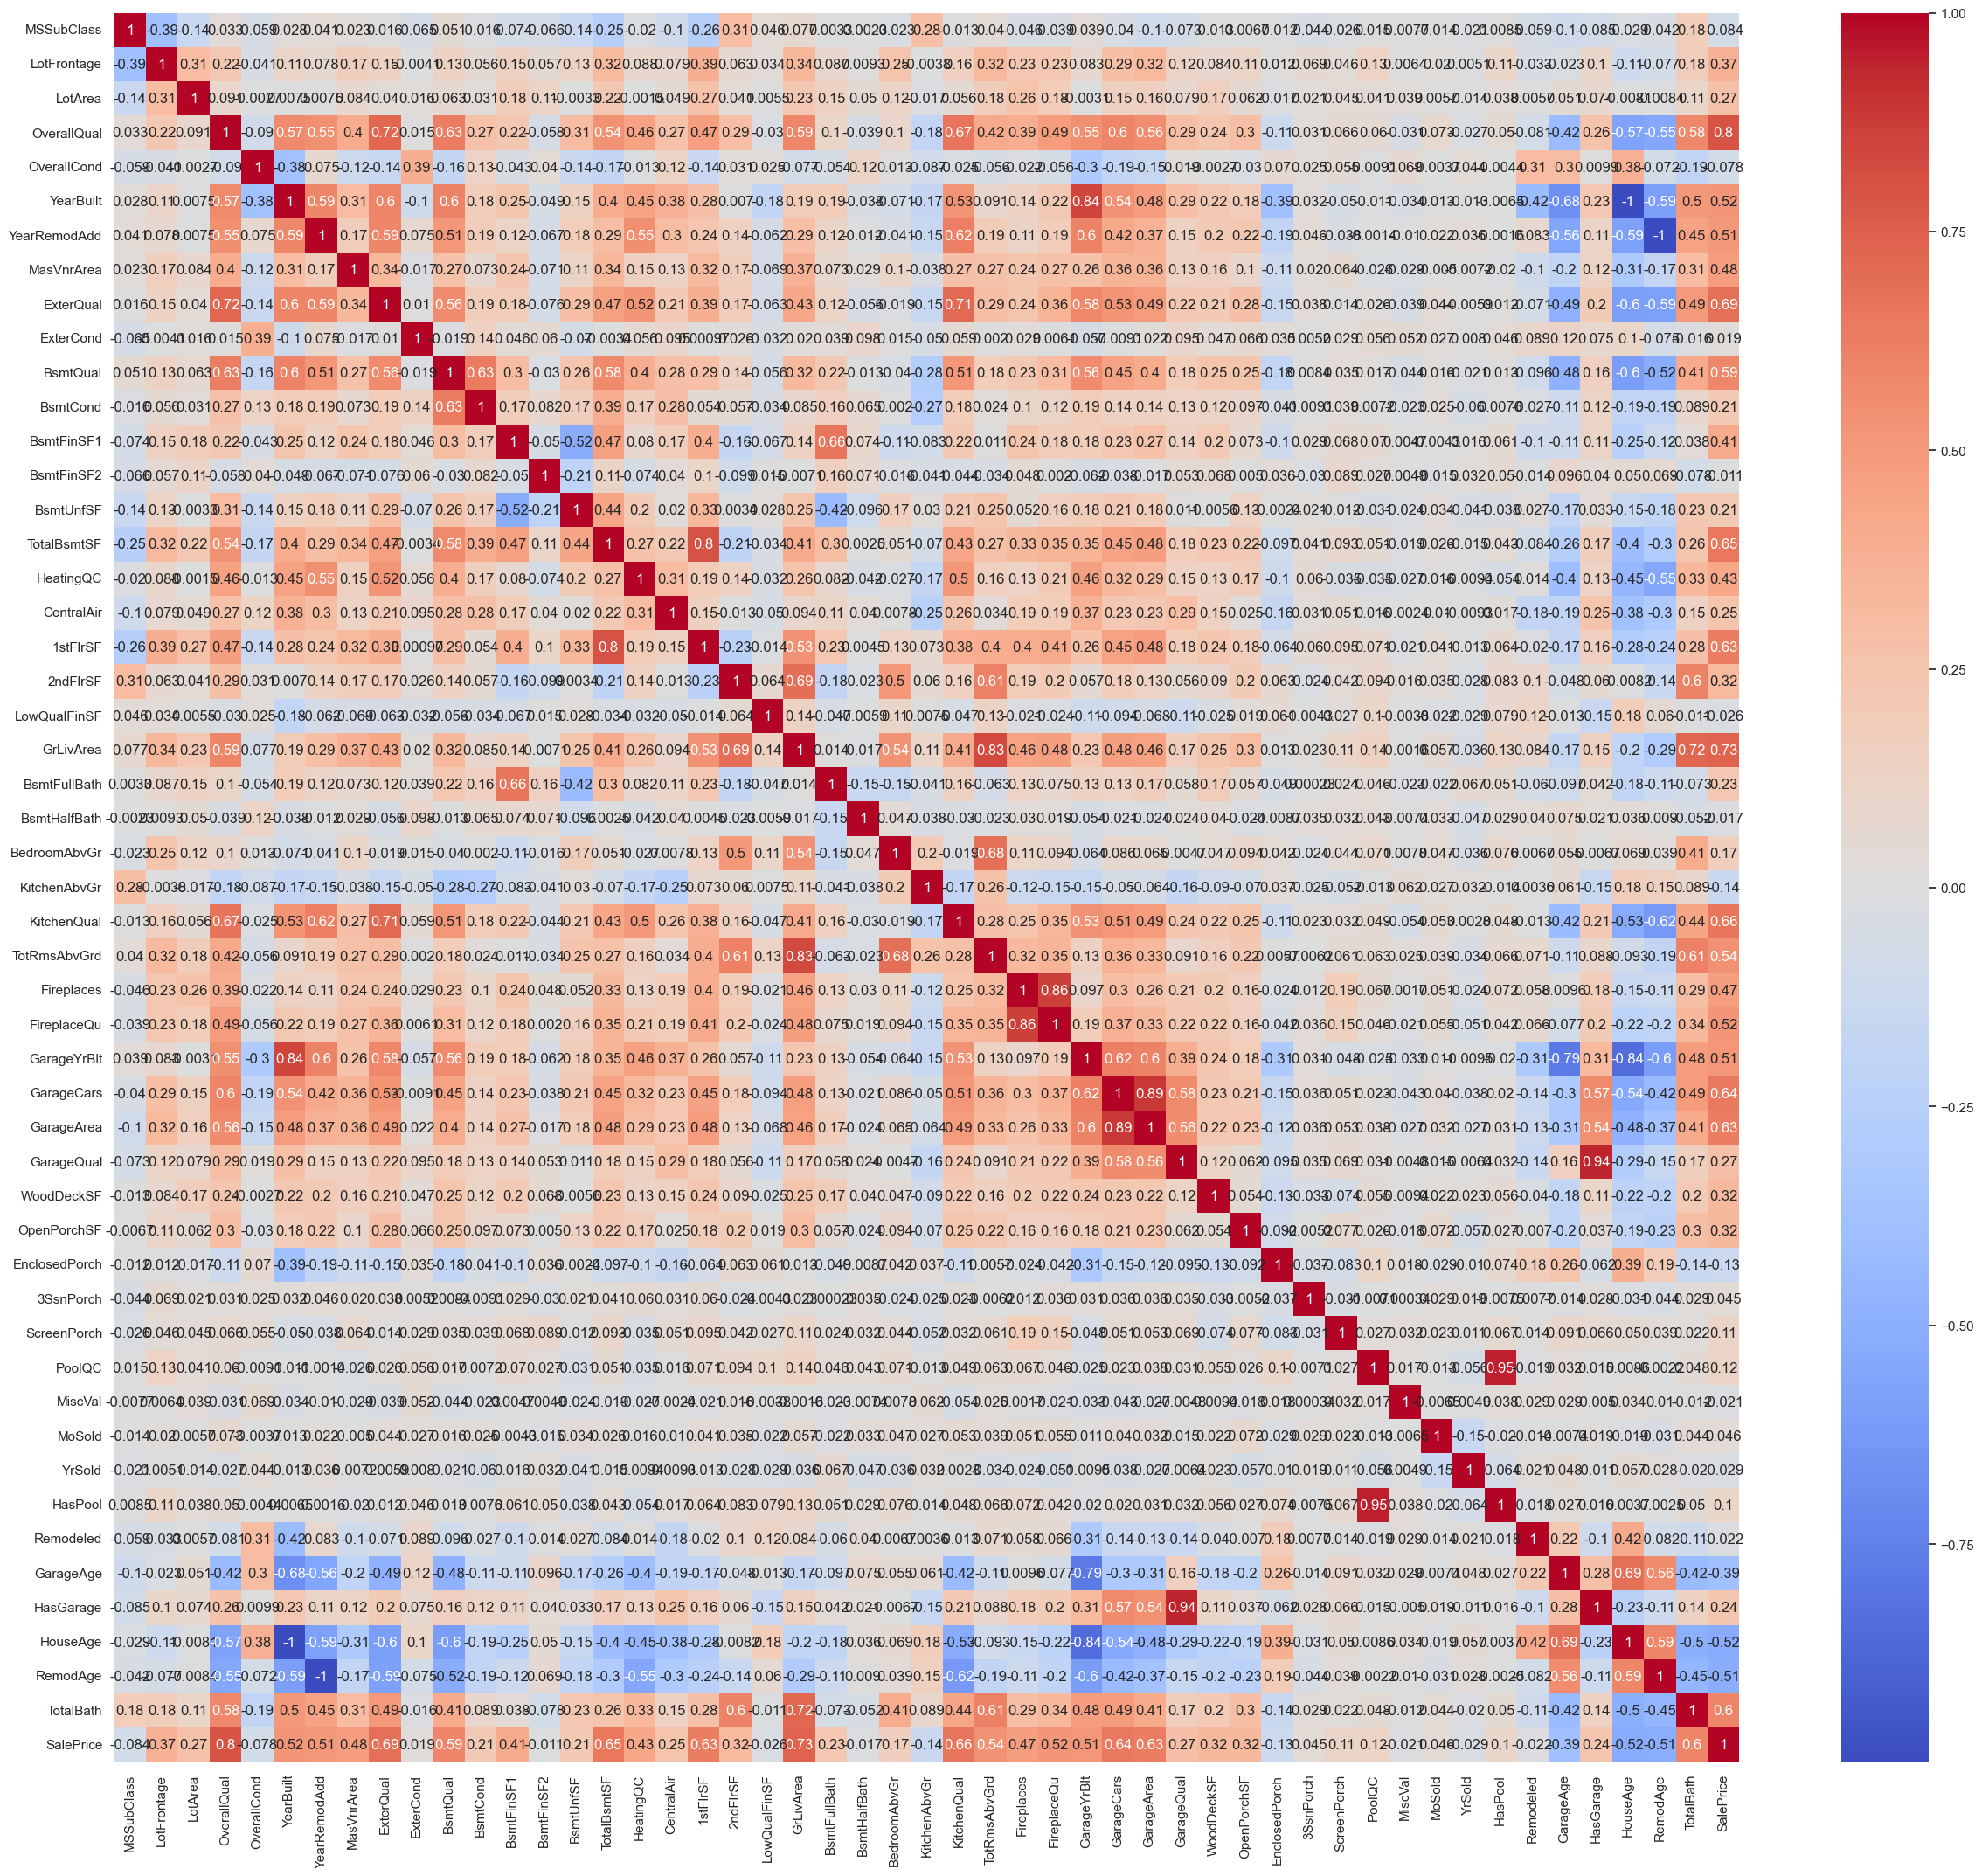

In [194]:
train_data['SalePrice'] = train_data.pop('SalePrice')

plt.figure(figsize = (30, 26))

sns.heatmap(
    train_data.corr(numeric_only = True),
    annot = True,
    cmap = 'coolwarm'
    )

### One-Hot Encoding (OHE)

In [195]:
train_data['MSSubClass'].unique()

array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
       180,  40])

In [196]:
for dataset in [train_data, test_data]:
    dataset['MSSubClass'] = dataset['MSSubClass'].astype(str)

In [197]:
categorical_features = train_data.select_dtypes(include = ['object', 'string']).columns.tolist()

In [198]:
import math

def  chart_cat(cat, df):
    cols_count = 2
    rows_count = math.ceil(len(cat) / cols_count)

    fig, axes = plt.subplots(rows_count, cols_count, figsize = ((14, 5 * rows_count)))
    axes = axes.flatten()
    for i, c in enumerate(cat):
        sns.boxplot(x = c, y = 'SalePrice', data = df, ax = axes[i], palette = 'Set2')
        axes[i].set_title(f'SalePrice by {c}')
        axes[i].tick_params(axis = 'x', rotation = 45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

    print('If P-value < 0.05, the sign is reliable')

    result = []
    for i, c in enumerate(cat):
        groups = [group['SalePrice'].values for name, group in df.groupby(c)]
        median = df.groupby(c)['SalePrice'].median()
        f_stats, p_val = stats.f_oneway(*groups)
        result.append({
            'Feature' : c,
            'P-value' : round(p_val, 5),
            'Median Min' : round(median.min(), 0),
            'Median Max' : round(median.max(), 0),
            'Median Diff' : round(median.max() - median.min(), 0)
        })
    result_df = pd.DataFrame(result)
    return result_df
    

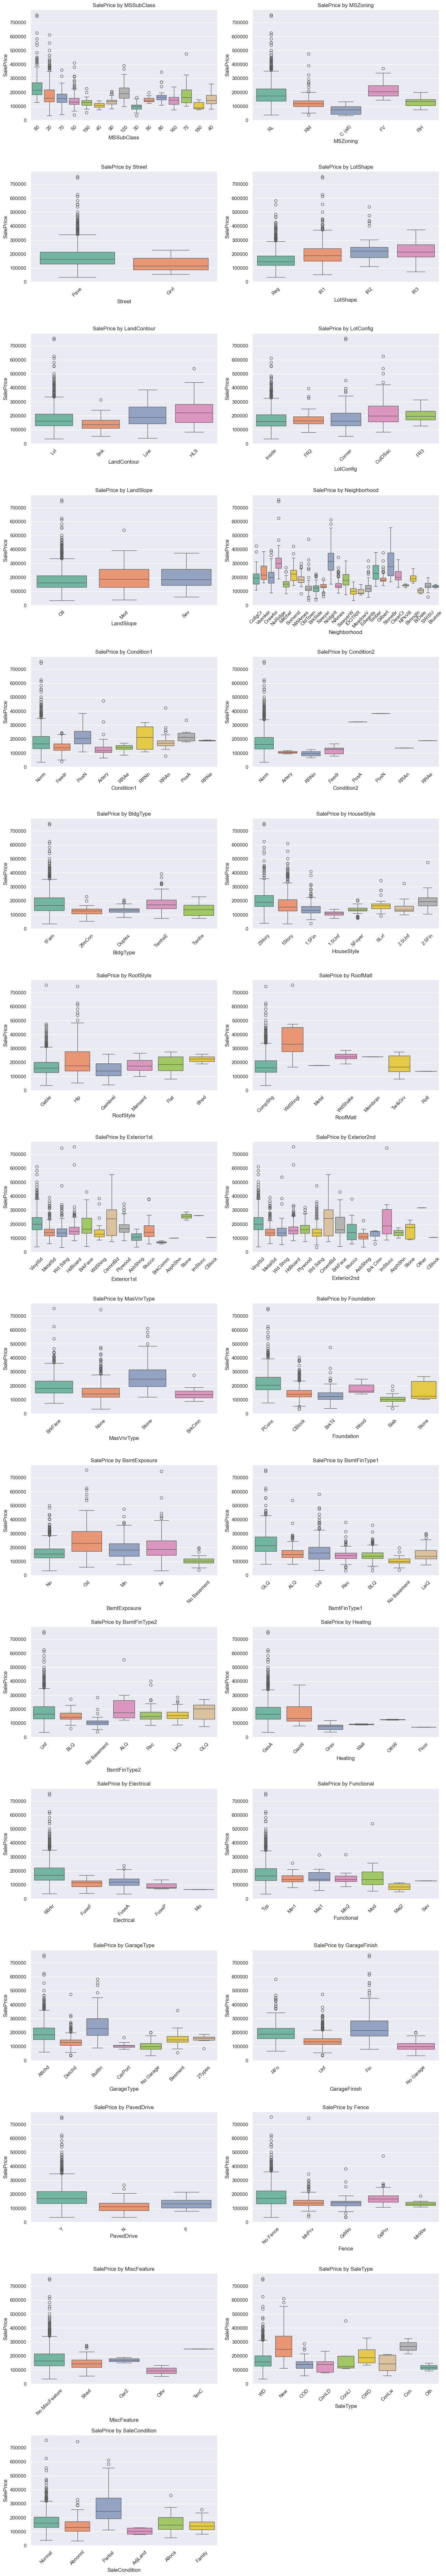

If P-value < 0.05, the sign is reliable


,Feature,P-value,Median Min,Median Max,Median Diff
0,MSSubClass,0.00000,88500.0,216000.0,127500.0
1,MSZoning,0.00000,74700.0,205950.0,131250.0
2,Street,0.11721,114250.0,163000.0,48750.0
3,LotShape,0.00000,146000.0,221000.0,75000.0
4,LandContour,0.00000,136500.0,222250.0,85750.0
5,LotConfig,0.00000,159500.0,199262.0,39762.0
6,LandSlope,0.14211,161875.0,186700.0,24825.0
7,Neighborhood,0.00000,88000.0,315000.0,227000.0
8,Condition1,0.00000,119550.0,214000.0,94450.0
9,Condition2,0.01366,96750.0,385000.0,288250.0


In [199]:
chart_cat(categorical_features, train_data)

## Prepare Features and Target

In [200]:
y = train_data['SalePrice']
X = train_data.drop(['SalePrice'], axis = 1)

## Train / Test Split

In [201]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

## Models

In [202]:
estimators = {
    'Linear Regression' : LinearRegression(),
    'Lasso' : Lasso(alpha = 0.1),
    'Ridge' : Ridge(alpha = 1.0),
    'ElasticNet': ElasticNet(alpha = 0.1, l1_ratio = 0.5),
    'Decision Tree' : DecisionTreeRegressor(max_depth = 6, random_state = 42),
    'Random Forest' : RandomForestRegressor(n_estimators = 100, random_state = 42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators = 100, random_state = 42),
    'Ada Boost' : AdaBoostRegressor(n_estimators = 100, random_state = 42),
    'XGboost' : XGBRegressor(random_state = 42),
    'Catboost' : CatBoostRegressor(verbose = 0, random_seed = 42),
    'Lightgbm' : LGBMRegressor(random_state = 42, verbose = -1),
    'SVR' : SVR(kernel = 'linear', C = 1, epsilon = 0.1),
    'LinearSVR': LinearSVR(C = 1, max_iter = 1000, dual = 'auto'),
    'NuSVR' : NuSVR(nu = 0.5, kernel = 'linear')
}

models = {}

for name, estimator in estimators.items():
    models[name] = Pipeline(steps = [
        ('preprocessor', ColumnTransformer([
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'),
         categorical_features)],
         remainder = Pipeline([
            ('scaler', StandardScaler())]))),
        ('model', estimator)
    ])

## Validation

In [203]:
mse_scorer = make_scorer(mean_squared_error, greater_is_better = False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better = False)
r2_scorer = make_scorer(r2_score)

results = []

for name, pipeline in models.items():
    mse_scores = -cross_val_score(pipeline, X_train, y_train, cv = 5, scoring = mse_scorer)
    rmse_scores = np.sqrt(mse_scores)
    mae_scores = -cross_val_score(pipeline, X_train, y_train, cv = 5, scoring = mae_scorer)
    r2_scores = cross_val_score(pipeline, X_train, y_train, cv = 5, scoring = r2_scorer)

    results.append({
        'Models': name,
        'RMSE_mean' : rmse_scores.mean(),
        'RMSE_std' : rmse_scores.std(),
        'MAE_mean' : mae_scores.mean(),
        'MAE_std' : mae_scores.std(),
        'R2_mean' : r2_scores.mean(),
        'R2_std' : r2_scores.std()
    })

df_results = pd.DataFrame(results).sort_values('RMSE_mean')
print(df_results)

               Models      RMSE_mean     RMSE_std       MAE_mean      MAE_std  \
9            Catboost   23426.841443  3118.041752   14694.538071  1316.658458   
6   Gradient Boosting   24287.360115  2676.011048   15885.117839  1200.119790   
10           Lightgbm   26245.052298  2562.773495   16608.952201  1066.725229   
8             XGboost   26789.066472  2961.041570   17325.939844  1103.658964   
3          ElasticNet   27800.013996  1756.345515   17866.681363   829.854515   
5       Random Forest   28082.314396  2093.016169   17484.155913  1400.402161   
2               Ridge   28171.281131  1969.276552   18816.458915   716.097026   
1               Lasso   32091.036853  5482.252911   20513.421291  1033.900417   
7           Ada Boost   32267.274116  2674.364062   23041.757904  1485.322249   
0   Linear Regression   32377.094524  5784.111381   20504.670797  1005.268288   
4       Decision Tree   40574.319862  4000.171231   26832.141915  2163.026177   
13              NuSVR   7572

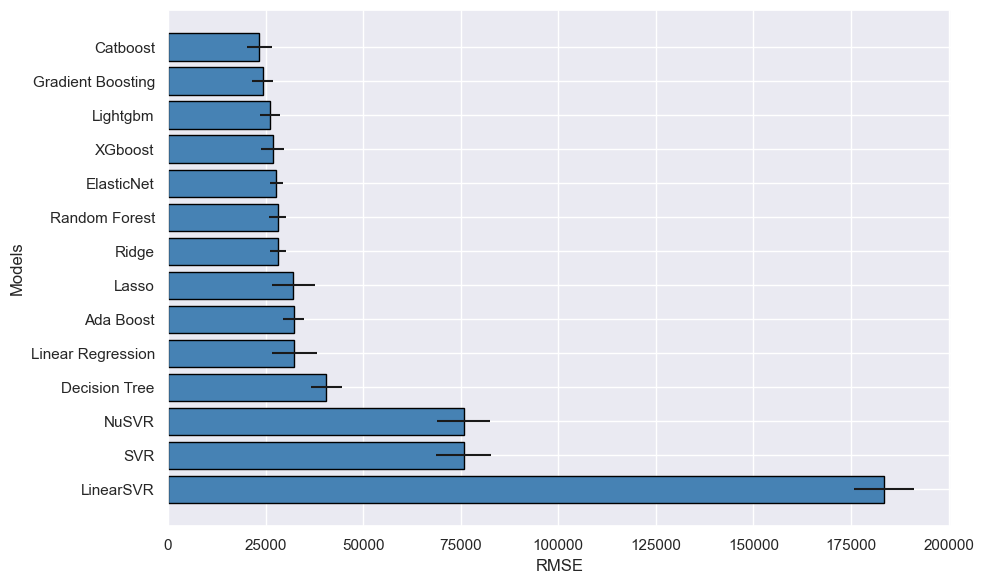

In [204]:
plt.figure(figsize = (10, 6))
plt.barh(df_results['Models'], df_results['RMSE_mean'],
         xerr = df_results['RMSE_std'], color = 'steelblue', edgecolor = 'black')
plt.xlabel('RMSE')
plt.ylabel('Models')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

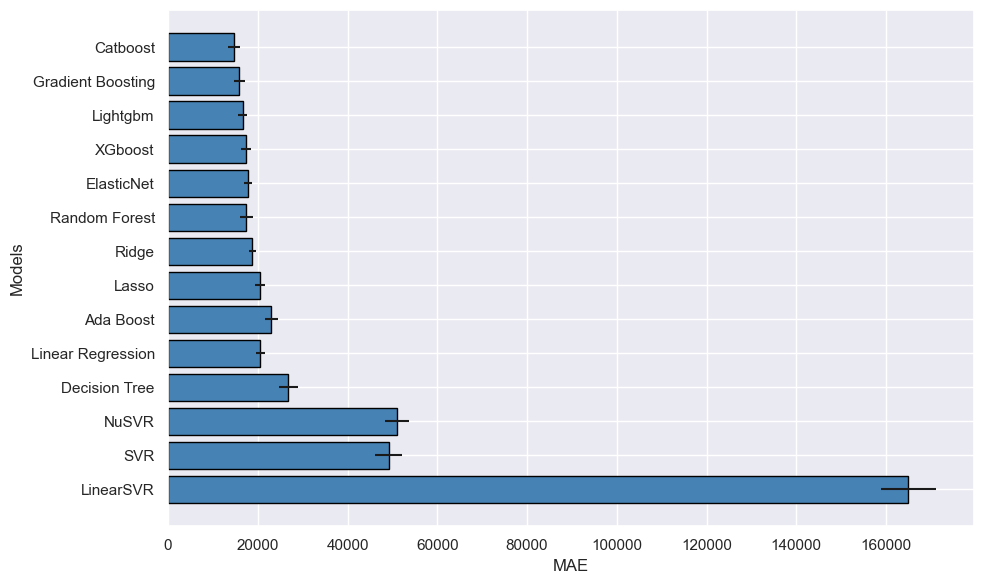

In [205]:
plt.figure(figsize = (10, 6))
plt.barh(df_results['Models'], df_results['MAE_mean'],
         xerr = df_results['MAE_std'], color = 'steelblue', edgecolor = 'black')
plt.xlabel('MAE')
plt.ylabel('Models')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

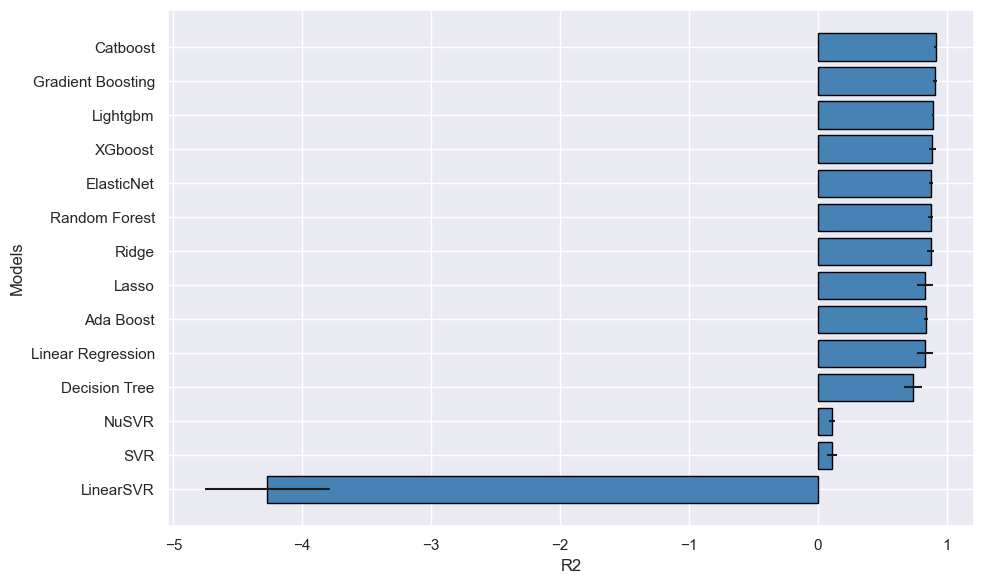

In [206]:
plt.figure(figsize = (10, 6))
plt.barh(df_results['Models'], df_results['R2_mean'],
         xerr = df_results['R2_std'], color = 'steelblue', edgecolor = 'black')
plt.xlabel('R2')
plt.ylabel('Models')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Permutation Importance

In [207]:
low_features_per_model = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    per_imp = permutation_importance(
        pipeline, X_test, y_test,
        n_repeats = 5,
        random_state = 42,
        scoring = 'r2'
    )

    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    sorted_idx = per_imp.importances_mean.argsort()
    low20_idx = sorted_idx[:20]

    df_low_feature = pd.DataFrame({
        'Feature' : feature_names[low20_idx],
        'Importance_mean' : per_imp.importances_mean[low20_idx],
        'Importance_std' : per_imp.importances_std[low20_idx]
    })
    low_features_per_model[name] = df_low_feature



In [208]:
for model_name, df_low in low_features_per_model.items():
    print(f"\n{'='*80}")
    print(f"Models: {model_name}")
    print(f"{'='*80}")
    display(df_low.round(5))


Models: Linear Regression


,Feature,Importance_mean,Importance_std
0,cat__HouseStyle_SFoyer,-0.00260,0.00159
1,cat__MSSubClass_30,-0.00152,0.00083
2,cat__MSSubClass_45,-0.00150,0.00257
3,cat__Neighborhood_Sawyer,-0.00109,0.00408
4,cat__Condition2_Feedr,-0.00103,0.00043
5,cat__MSSubClass_60,-0.00102,0.00077
6,cat__Street_Pave,-0.00087,0.00092
7,cat__Condition2_PosN,-0.00068,0.00144
8,cat__MSSubClass_75,-0.00066,0.00091
9,cat__Condition1_RRNn,-0.00049,0.00042



Models: Lasso


,Feature,Importance_mean,Importance_std
0,cat__Neighborhood_NPkVill,-0.00273,0.00161
1,cat__HouseStyle_SFoyer,-0.00260,0.00162
2,cat__Neighborhood_NAmes,-0.00167,0.00040
3,cat__MSSubClass_30,-0.00153,0.00083
4,cat__MSSubClass_45,-0.00150,0.00256
5,cat__Neighborhood_Sawyer,-0.00106,0.00404
6,cat__Condition2_Feedr,-0.00103,0.00043
7,cat__MSSubClass_60,-0.00103,0.00077
8,cat__Street_Pave,-0.00094,0.00090
9,cat__Condition2_PosN,-0.00069,0.00142



Models: Ridge


...

,Feature,Importance_mean,Importance_std
0,cat__Condition2_Feedr,-0.00005,0.00005
1,cat__BldgType_TwnhsE,-0.00001,0.00006
2,cat__Condition2_PosA,-0.00001,0.00006
3,cat__Condition2_RRAn,-0.00001,0.00000
4,cat__Neighborhood_NoRidge,-0.00000,0.00000
5,cat__Neighborhood_Crawfor,-0.00000,0.00000
6,cat__Neighborhood_BrkSide,-0.00000,0.00001
7,cat__MSSubClass_30,0.00000,0.00000
8,cat__BldgType_2fmCon,0.00000,0.00000
9,cat__MSSubClass_80,0.00000,0.00000



Models: LinearSVR


,Feature,Importance_mean,Importance_std
0,cat__MSSubClass_40,-0.00350,0.00040
1,cat__LandSlope_Mod,-0.00288,0.00077
2,cat__BldgType_Duplex,-0.00261,0.00032
3,cat__LandContour_HLS,-0.00242,0.00026
4,cat__Condition1_Feedr,-0.00229,0.00019
5,cat__MSSubClass_45,-0.00116,0.00063
6,cat__BldgType_Twnhs,-0.00091,0.00010
7,cat__Street_Pave,-0.00080,0.00032
8,cat__MSSubClass_50,-0.00051,0.00034
9,cat__MSSubClass_70,-0.00020,0.00008



Models: NuSVR


,Feature,Importance_mean,Importance_std
0,cat__Condition2_Feedr,-0.00004,0.00004
1,cat__Condition2_PosA,-0.00001,0.00006
2,cat__BldgType_TwnhsE,-0.00001,0.00005
3,cat__Neighborhood_NoRidge,-0.00001,0.00001
4,cat__Condition2_RRAn,-0.00000,0.00000
5,cat__Neighborhood_Crawfor,-0.00000,0.00000
6,cat__Neighborhood_BrkSide,-0.00000,0.00002
7,cat__MSSubClass_30,0.00000,0.00000
8,cat__MSSubClass_80,0.00000,0.00000
9,cat__LotShape_IR2,0.00000,0.00000


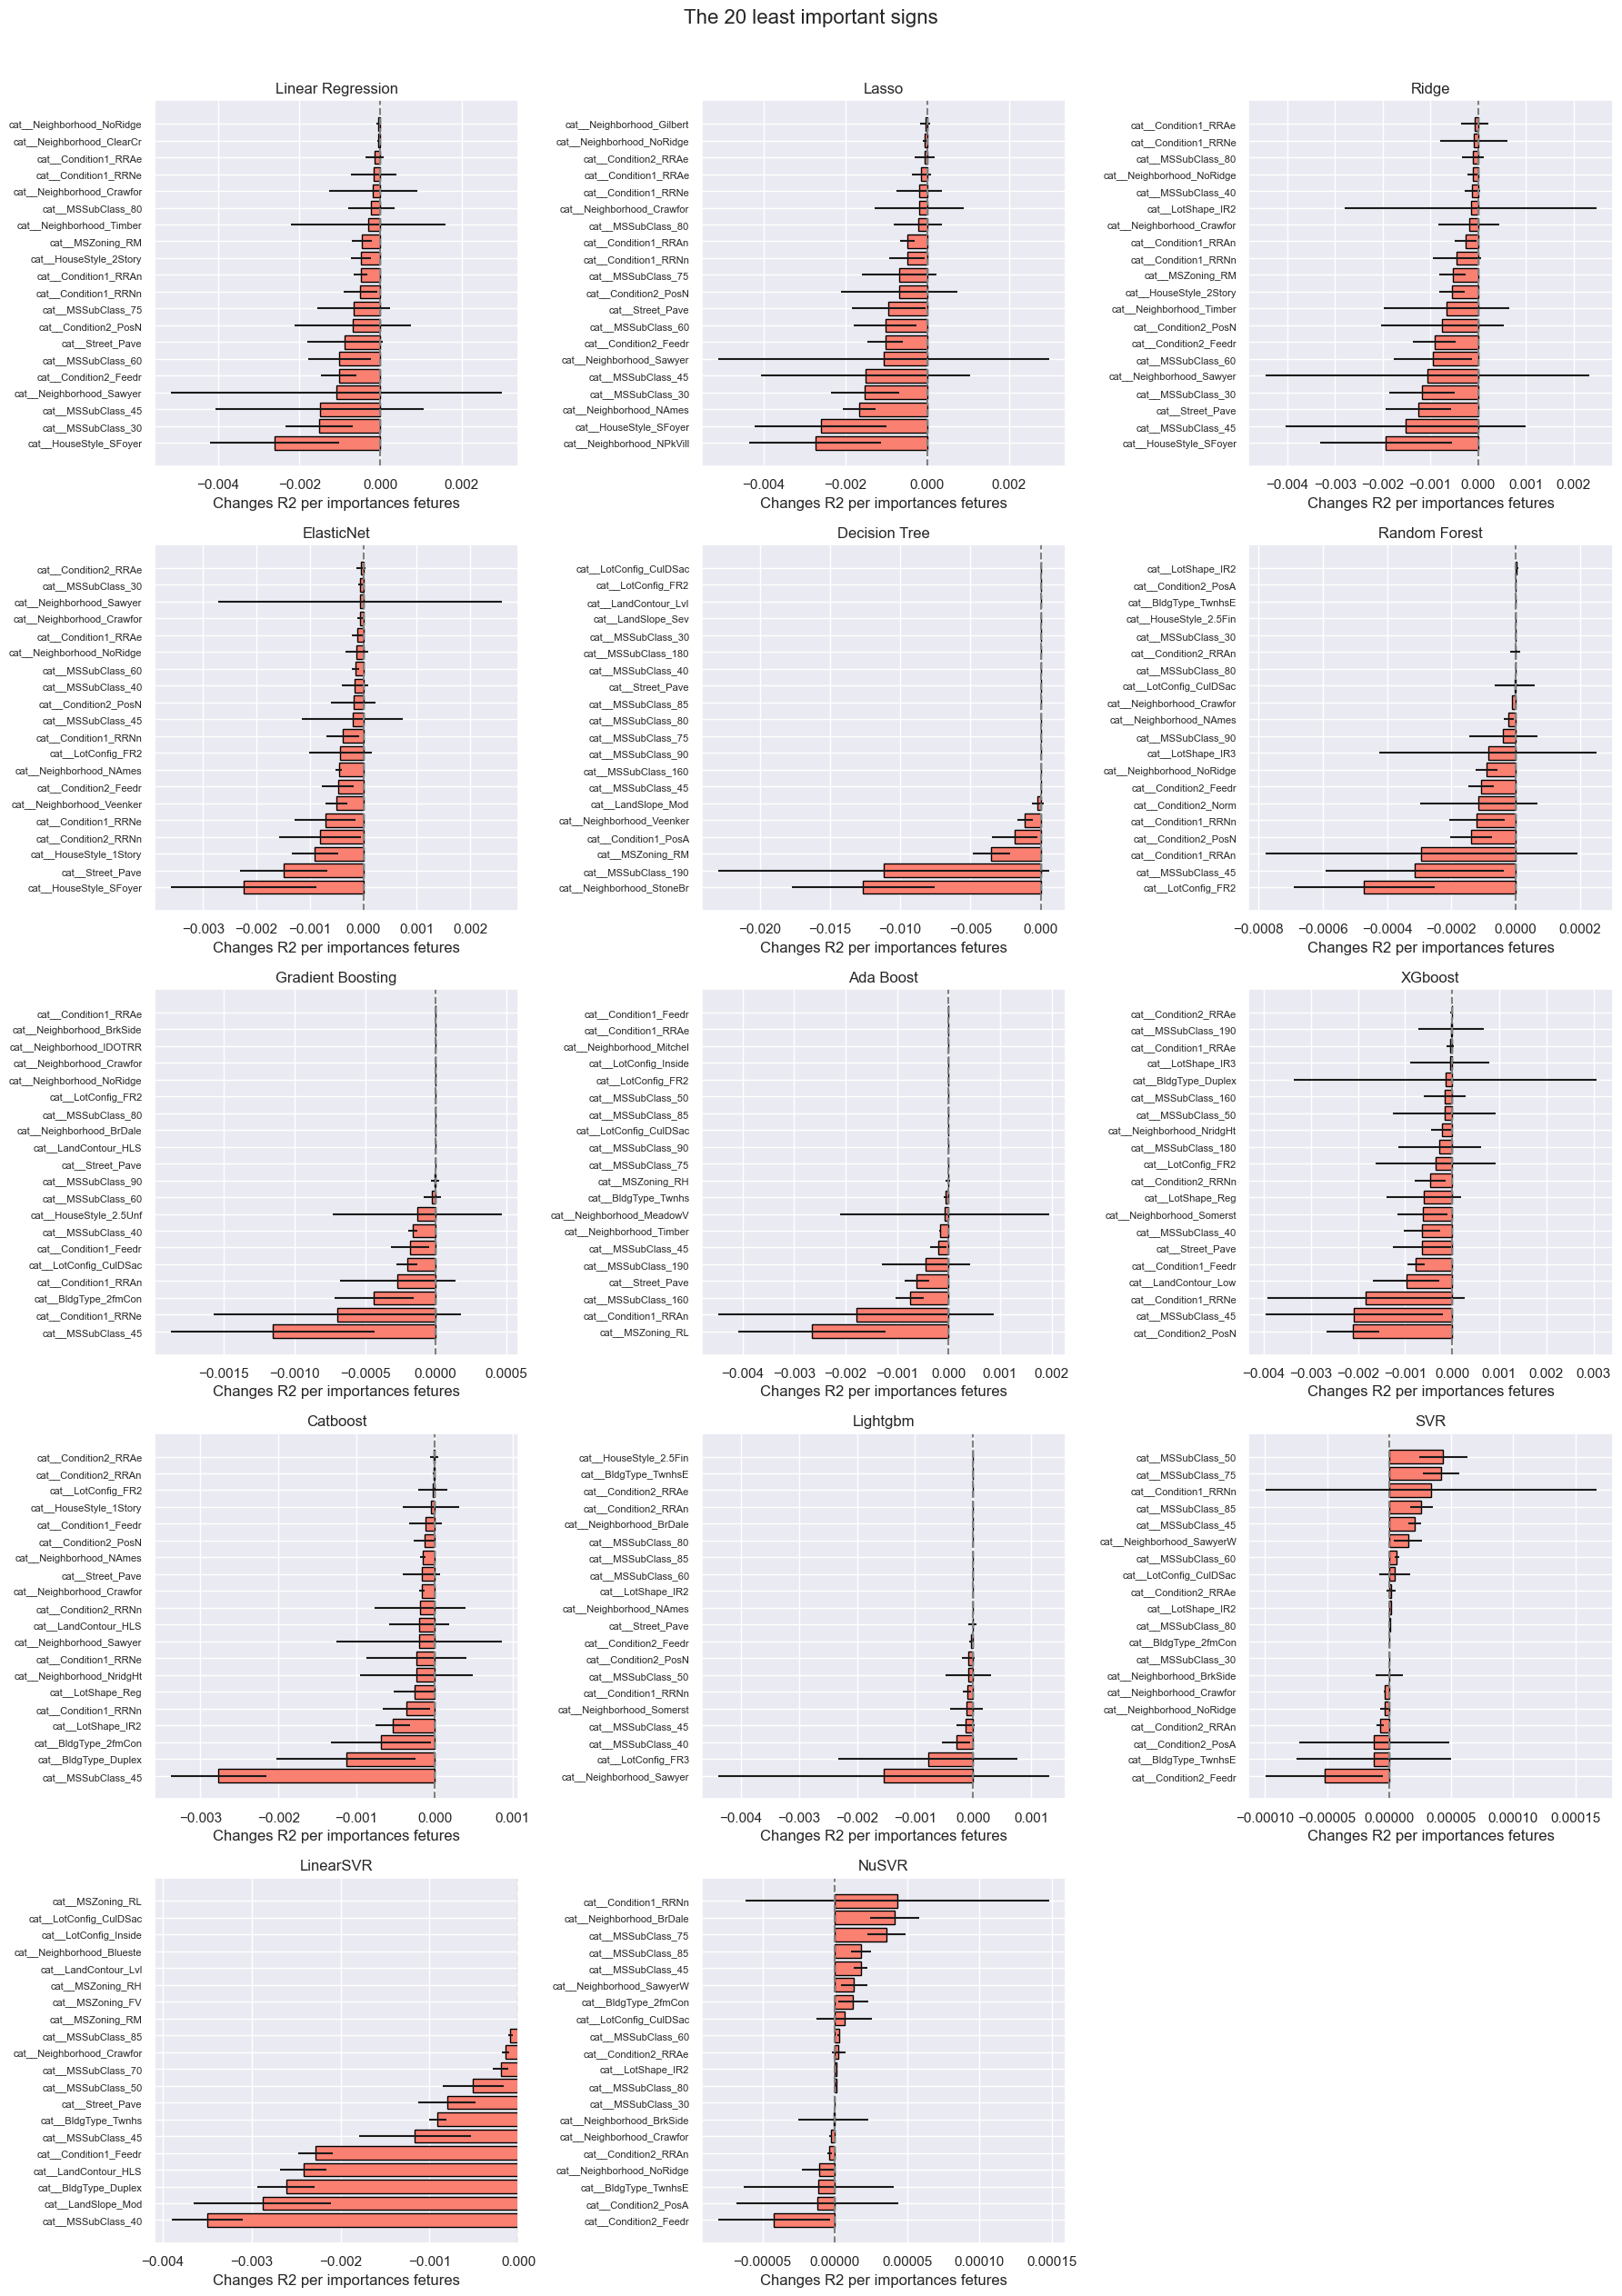

In [209]:
n_models = len(models)
n_cols = 3
n_rows = (n_models - 1)//n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize = (n_cols * 6, n_rows * 5))
axes = axes.flatten()

for idx, (model_name, df_low) in enumerate(low_features_per_model.items()):
    ax = axes[idx]
    y_pos = range(len(df_low))
    ax.barh(y_pos, df_low['Importance_mean'],
            xerr = df_low['Importance_std'], color = 'salmon', edgecolor = 'black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_low['Feature'], fontsize = 8)
    ax.set_title(model_name, fontsize = 12)
    ax.set_xlabel('Changes R2 per importances fetures')
    ax.axvline(0, color = 'grey', linestyle = '--')

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])


plt.suptitle('The 20 least important signs', fontsize = 16, y = 1.01)
plt.tight_layout()
plt.show()

## Models Training

In [210]:
f_model = models['Catboost']
param_dist = {
    'model__depth' : randint(4, 10),
    'model__learning_rate' : uniform(0.01, 0.2),
    'model__iterations' : randint(200, 1000),
    'model__l2_leaf_reg' : uniform(1, 10),
    'model__border_count' : randint(32, 255)
}
random_search = RandomizedSearchCV(
    estimator = f_model,
    param_distributions = param_dist,
    n_iter = 20,
    cv = 3,
    scoring = 'neg_mean_squared_error',
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__border_count': <scipy.stats....002110C75F450>, 'model__depth': <scipy.stats....002110F1D66D0>, 'model__iterations': <scipy.stats....002110F1B8210>, 'model__l2_leaf_reg': <scipy.stats....00211663FFE10>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same acro

### Validation

In [ ]:
print(random_search.best_params_)

best_rmse = np.sqrt(-random_search.best_score_)
print(f"Best RMSE on cross-validation: {best_rmse:.2f}")


y_pred_test = random_search.best_estimator_.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"RMSE on test set: {test_rmse:.2f}")

{'model__border_count': 120, 'model__depth': 4, 'model__iterations': 674, 'model__l2_leaf_reg': np.float64(7.118528947223795), 'model__learning_rate': np.float64(0.03789877213040837)}
Лучший RMSE на кросс-валидации: 23462.27
RMSE на тестовой выборке: 21142.79


### Best model training

In [212]:
best_model = random_search.best_estimator_
best_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## Validation

In [213]:
predictions = best_model.predict(test_data)

## Predict Test Dataset

In [214]:
output = pd.DataFrame({
    'Id' : test_data['Id'],
    'SalePrice' : predictions,
})
output.to_csv('data/submission.csv', index = False)
print ('Your permission saved!')

Your permission saved!
